# Amazon review sentiment: technical report

**Team:** 4  
**Members:** 
**Course deadline:** May 18, 2026  
**Dataset:** [Amazon Reviews (Kaggle)](https://www.kaggle.com/datasets/bittlingmayer/amazonreviews)

---

## 1. Introduction

This report analyzes **Option 4 (Amazon Reviews)** from the course specification: a large, publicly available English review corpus suited to **NLP**, **representation learning**, and **Transformer** modeling.

**Problem.** Given the text of an Amazon product review, predict binary sentiment: negative (`0`) vs positive (`1`).

**Data.** The fastText-formatted polarity release provides:

- `train.ft.txt` — development, model fitting, and internal validation only.
- `test.ft.txt` — held out until Section 7.3 for a single locked evaluation.

**Assumptions.** Reviews are in English; labels reflect expressed sentiment in text (not causal product quality); selection bias exists because only some customers review. We treat the task as **associative prediction** under the observed support, not causal inference.

The workflow proceeds from **data specification and quality assurance**, through **exploratory analysis and problem framing**, **baseline and classical predictors**, **unsupervised structure discovery**, **neural and Transformer-based models**, to **evaluation integrity, leakage audit, and conclusions** (Section 7).

### 1.1 Report outline

| Section | Content |
|---------|---------|
| Section 2 | Data schema, quality checks, dataset overview |
| Section 3 | DGP narrative, EDA, assumptions, feature-engineering decisions |
| Section 4 | TF–IDF + linear baselines + Random Forest; length ablation (4.4) |
| Section 5 | Unsupervised clustering (TF–IDF→SVD, embeddings) |
| Section 6 | MLP and DistilBERT; attention; ablations; model comparison |
| Section 7 | Leakage audit, 5-fold CV, locked `test.ft.txt` evaluation, conclusions |

### 1.2 Execution checklist

1. **Restart kernel** and run all cells top-to-bottom (or through Section 6.5, then Section 7).
2. **Do not** open `test.ft.txt` until Section 7.3.
3. Section 7.4 conclusions reference locked-test metrics from Section 7.3 outputs.
4. **Slow cells:** Section 4 baselines and Random Forest (~500k rows), Section 4.4 length ablation, DistilBERT training (Section 6), Section 6 truncation ablation, Section 7.2 CV, Section 7.3 locked refit + full test predict.


In [1]:
from pathlib import Path
from collections import Counter
import random
import os

import pandas as pd

DATA_DIR = Path("data")
TRAIN_PATH = DATA_DIR / "train.ft.txt"
TEST_PATH = DATA_DIR / "test.ft.txt"

KAGGLE_URL = "https://www.kaggle.com/datasets/bittlingmayer/amazonreviews"

if not TRAIN_PATH.exists() or not TEST_PATH.exists():
    missing = [p for p in (TRAIN_PATH, TEST_PATH) if not p.exists()]
    print("ERROR: Required data files not found.")
    print(f"  Download from: {KAGGLE_URL}")
    print("  Place extracted files at:")
    print(f"    {TRAIN_PATH.resolve()}")
    print(f"    {TEST_PATH.resolve()}")
    print(f"  Working directory: {os.getcwd()}")
    raise FileNotFoundError(f"Missing: {', '.join(str(p) for p in missing)}")

assert TRAIN_PATH.exists(), f"Missing file: {TRAIN_PATH.resolve()}"
assert TEST_PATH.exists(), f"Missing file: {TEST_PATH.resolve()}"

RANDOM_SEED = 42
random.seed(RANDOM_SEED)

# Model-selection policy (Section 4.1, Section 6.4, Section 7.2); keep names consistent across the notebook
PRIMARY_METRIC = "f1"
TIE_BREAK_METRIC = "roc_auc"


In [2]:
def parse_fasttext_line(line: str):
    """Parse a fastText row into canonical fields.

    Expected format: __label__X <free text>
    Returns: (label_raw, label, text, is_malformed)
    """
    raw = line.rstrip("\n")

    if not raw.startswith("__label__"):
        return None, None, "", True

    parts = raw.split(" ", 1)
    if len(parts) == 1:
        label_raw = parts[0]
        text = ""
    else:
        label_raw, text = parts[0], parts[1]

    label_map = {"__label__1": 0, "__label__2": 1}
    label = label_map.get(label_raw)
    is_malformed = label is None

    return label_raw, label, text, is_malformed


def profile_fasttext_file(path: Path):
    label_counts_raw = Counter()
    label_counts_mapped = Counter()

    row_count = 0
    malformed_rows = 0
    empty_text_rows = 0

    valid_rows = 0
    char_len_sum = 0
    word_len_sum = 0
    char_len_freq = Counter()
    word_len_freq = Counter()

    with path.open("r", encoding="utf-8", errors="replace") as f:
        for line in f:
            row_count += 1
            label_raw, label, text, malformed = parse_fasttext_line(line)

            if malformed:
                malformed_rows += 1
                continue

            label_counts_raw[label_raw] += 1
            label_counts_mapped[label] += 1

            stripped = text.strip()
            if not stripped:
                empty_text_rows += 1

            valid_rows += 1
            char_len = len(text)
            word_len = len(stripped.split()) if stripped else 0

            char_len_sum += char_len
            word_len_sum += word_len
            char_len_freq[char_len] += 1
            word_len_freq[word_len] += 1

    def pct(count: int, total: int) -> float:
        return (100.0 * count / total) if total else 0.0

    def quantile_from_freq(freq: Counter, total: int, q: float):
        if total == 0:
            return None
        target = max(1, int(q * total))
        running = 0
        for value in sorted(freq):
            running += freq[value]
            if running >= target:
                return value
        return max(freq)

    profile = {
        "file": str(path),
        "row_count": row_count,
        "malformed_rows": malformed_rows,
        "empty_text_rows": empty_text_rows,
        "label_counts_raw": dict(label_counts_raw),
        "label_counts_mapped": dict(label_counts_mapped),
        "label_0_pct": pct(label_counts_mapped.get(0, 0), valid_rows),
        "label_1_pct": pct(label_counts_mapped.get(1, 0), valid_rows),
        "char_len_mean": (char_len_sum / valid_rows) if valid_rows else None,
        "char_len_median": quantile_from_freq(char_len_freq, valid_rows, 0.50),
        "char_len_p95": quantile_from_freq(char_len_freq, valid_rows, 0.95),
        "word_len_mean": (word_len_sum / valid_rows) if valid_rows else None,
        "word_len_median": quantile_from_freq(word_len_freq, valid_rows, 0.50),
        "word_len_p95": quantile_from_freq(word_len_freq, valid_rows, 0.95),
    }

    return profile


def sample_rows(path: Path, n: int = 5, seed: int = 42):
    rng = random.Random(seed)
    reservoir = []

    with path.open("r", encoding="utf-8", errors="replace") as f:
        for i, line in enumerate(f, start=1):
            label_raw, label, text, malformed = parse_fasttext_line(line)
            if malformed:
                continue
            row = {"label_raw": label_raw, "label": label, "text": text[:200]}

            if len(reservoir) < n:
                reservoir.append(row)
            else:
                j = rng.randint(1, i)
                if j <= n:
                    reservoir[j - 1] = row

    return pd.DataFrame(reservoir)

In [3]:
train_profile = profile_fasttext_file(TRAIN_PATH)
test_profile = profile_fasttext_file(TEST_PATH)

profile_df = pd.DataFrame([train_profile, test_profile])

display_cols = [
    "file",
    "row_count",
    "malformed_rows",
    "empty_text_rows",
    "label_counts_raw",
    "label_counts_mapped",
    "label_0_pct",
    "label_1_pct",
    "char_len_mean",
    "char_len_median",
    "char_len_p95",
    "word_len_mean",
    "word_len_median",
    "word_len_p95",
]

profile_df[display_cols]

,file,row_count,malformed_rows,empty_text_rows,label_counts_raw,label_counts_mapped,label_0_pct,label_1_pct,char_len_mean,char_len_median,char_len_p95,word_len_mean,word_len_median,word_len_p95
0,data/train.ft.txt,3600000,0,0,"{'__label__2': 1800000, '__label__1': 1800000}","{1: 1800000, 0: 1800000}",50.0,50.0,431.646315,383,895,78.482733,70,161
1,data/test.ft.txt,400000,0,0,"{'__label__2': 200000, '__label__1': 200000}","{1: 200000, 0: 200000}",50.0,50.0,431.429630,383,895,78.424145,70,161


## 2. Data specification and quality assurance

**Canonical record schema** (after parsing):

- `label_raw` (`str`): original fastText label (`__label__1` or `__label__2`).
- `label` (`int`): mapped class (`0` negative, `1` positive).
- `text` (`str`): raw review text.

Before any modeling we follow a sequential quality check:

- Count of malformed rows (unparseable label prefix).
- Count of empty or whitespace-only texts.
- Class distribution (train and held-out test).
- Text length summaries (characters and words): central tendency and upper tails.

**Evaluation integrity:**

- `test.ft.txt` is **held out** until the final reporting step; it must not inform preprocessing fit, hyperparameter tuning, or model selection.
- All development and tuning use **splits drawn from `train.ft.txt` only**.
- Any learned object (vectorizer, tokenizer statistics, scalers) is **fit on training folds or the training partition only**, then applied transform-only to validation and, once, to the held-out test.


### 2.1 Dataset at a glance

Console summary for graders and first-time runs (reuses `profile_fasttext_file` results; no extra full-file scan).


In [4]:
def print_dataset_overview(train_prof, test_prof, train_path: Path, sample_seed: int = 42):
    """Human-readable dataset summary (reference template STEP 1.4 style)."""
    print("=" * 72)
    print("DATASET OVERVIEW")
    print("=" * 72)

    print("\nLabel mapping (fastText → model):")
    print("  __label__1  →  0  (negative)")
    print("  __label__2  →  1  (positive)")

    for name, prof in [("Train", train_prof), ("Test (held out)", test_prof)]:
        print("\n" + "-" * 72)
        print(name.upper())
        print("-" * 72)
        print(f"  File: {prof['file']}")
        print(f"  Rows scanned: {prof['row_count']:,}")
        print(f"  Malformed rows: {prof['malformed_rows']:,}")
        print(f"  Empty text rows: {prof['empty_text_rows']:,}")
        n0 = prof["label_counts_mapped"].get(0, 0)
        n1 = prof["label_counts_mapped"].get(1, 0)
        total = n0 + n1
        print(f"  Class 0 (negative): {n0:,} ({prof['label_0_pct']:.1f}%)")
        print(f"  Class 1 (positive): {n1:,} ({prof['label_1_pct']:.1f}%)")
        if name == "Train":
            balanced = abs(prof["label_0_pct"] - prof["label_1_pct"]) < 5.0
            print(f"  Class balance: {'BALANCED' if balanced else 'IMBALANCED'}")
        print(f"  Characters — mean: {prof['char_len_mean']:.0f}, median: {prof['char_len_median']}, p95: {prof['char_len_p95']}")
        print(f"  Words      — mean: {prof['word_len_mean']:.1f}, median: {prof['word_len_median']}, p95: {prof['word_len_p95']}")

    print("\n" + "-" * 72)
    print("SAMPLE REVIEWS (from training file)")
    print("-" * 72)
    pool = sample_rows(train_path, n=40, seed=sample_seed)
    neg = pool[pool["label"] == 0]
    pos = pool[pool["label"] == 1]
    if len(neg):
        print("\nExample NEGATIVE (label 0):")
        print(f"  {neg.iloc[0]['text']}...")
    if len(pos):
        print("\nExample POSITIVE (label 1):")
        print(f"  {pos.iloc[0]['text']}...")
    print("\n" + "=" * 72)
    print("Ready for modeling sections.\n")


print_dataset_overview(train_profile, test_profile, TRAIN_PATH, sample_seed=RANDOM_SEED)


DATASET OVERVIEW

Label mapping (fastText → model):
  __label__1  →  0  (negative)
  __label__2  →  1  (positive)

------------------------------------------------------------------------
TRAIN
------------------------------------------------------------------------
  File: data/train.ft.txt
  Rows scanned: 3,600,000
  Malformed rows: 0
  Empty text rows: 0
  Class 0 (negative): 1,800,000 (50.0%)
  Class 1 (positive): 1,800,000 (50.0%)
  Class balance: BALANCED
  Characters — mean: 432, median: 383, p95: 895
  Words      — mean: 78.5, median: 70, p95: 161

------------------------------------------------------------------------
TEST (HELD OUT)
------------------------------------------------------------------------
  File: data/test.ft.txt
  Rows scanned: 400,000
  Malformed rows: 0
  Empty text rows: 0
  Class 0 (negative): 200,000 (50.0%)
  Class 1 (positive): 200,000 (50.0%)
  Characters — mean: 431, median: 383, p95: 895
  Words      — mean: 78.4, median: 70, p95: 161

------------

In [5]:
print("Train sample rows")
display(sample_rows(TRAIN_PATH, n=5, seed=RANDOM_SEED))

print("\nTest sample rows")
display(sample_rows(TEST_PATH, n=5, seed=RANDOM_SEED))

Train sample rows


,label_raw,label,text
0,__label__1,0,"Dislike!: After reading the reviews, I bought ..."
1,__label__1,0,Not Worth The Money: Can get the very same pro...
2,__label__2,1,LIFE-CHANGING PRODUCT!: I purchased this juice...
3,__label__1,0,Is it supposed to be a joke?: Fought my way th...
4,__label__2,1,Tears and amazment: I was raised in the Baptis...



Test sample rows


,label_raw,label,text
0,__label__1,0,Meh: I know this is an indie film and I usuall...
1,__label__1,0,Spacesaver: These are truly a space saver. How...
2,__label__2,1,Fabulous for dry hair straightening: I can't s...
3,__label__2,1,A different approach: I think this step was a ...
4,__label__1,0,"Here today, gone tomorrow: Horrible product, j..."


## 3. Problem framing and exploratory analysis

### 3.1 Predictive objective and data-generating narrative

The task is **predictive**: given review text, estimate the probability of negative (`0`) versus positive (`1`) sentiment.

**Narrative of the data-generating process:**

1. A customer purchases a product and forms an experience.
2. Latent factors (perceived quality, expectations, shipping, category norms, reviewer strictness) influence sentiment.
3. Only a subset of customers author a public review (**selection**).
4. Sentiment is expressed in natural language and aggregated into the observed label.

**Observed quantities:** text and label. **Unobserved factors** include baseline product quality, reviewer personality, price and seasonality, and platform-specific behavior.

**Recognized biases:** selection into reviewing; category-driven vocabulary; wide variation in verbosity; possible **domain shift** over time or product mix.

**Scope of inference:** findings are interpreted as **associative prediction** under the observed support, not as causal claims from language to product quality. Generalization is assessed under **fixed, leakage-safe** train/validation/test protocols.

### 3.2 Exploratory analysis and computational note

Exploratory section uses a **random reservoir sample** of size `EDA_SAMPLE_SIZE` from the training file for tractability on large corpora. A sufficiently large sample preserves stable marginal patterns (balance, length, broad lexical signal) while keeping iteration cost manageable for repeated checks.


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

In [7]:
def build_eda_sample(path: Path, n: int = 200_000, seed: int = 42):
    """Reservoir sample rows from the training file for fast EDA."""
    rng = random.Random(seed)
    reservoir = []

    with path.open("r", encoding="utf-8", errors="replace") as f:
        for i, line in enumerate(f, start=1):
            label_raw, label, text, malformed = parse_fasttext_line(line)
            if malformed:
                continue

            row = {
                "label_raw": label_raw,
                "label": label,
                "text": text,
            }

            if len(reservoir) < n:
                reservoir.append(row)
            else:
                j = rng.randint(1, i)
                if j <= n:
                    reservoir[j - 1] = row

    eda_df = pd.DataFrame(reservoir)
    eda_df["char_len"] = eda_df["text"].str.len()
    eda_df["word_len"] = eda_df["text"].str.split().str.len()
    eda_df["label_name"] = eda_df["label"].map({0: "negative", 1: "positive"})

    return eda_df


EDA_SAMPLE_SIZE = 200_000
eda_df = build_eda_sample(TRAIN_PATH, n=EDA_SAMPLE_SIZE, seed=RANDOM_SEED)
eda_df.shape

(200000, 6)

In [8]:
eda_summary = {
    "sample_rows": len(eda_df),
    "label_distribution": eda_df["label_name"].value_counts(normalize=True).round(4).to_dict(),
    "char_len_median": int(eda_df["char_len"].median()),
    "char_len_p95": int(eda_df["char_len"].quantile(0.95)),
    "word_len_median": int(eda_df["word_len"].median()),
    "word_len_p95": int(eda_df["word_len"].quantile(0.95)),
}

eda_summary

{'sample_rows': 200000,
 'label_distribution': {'positive': 0.5014, 'negative': 0.4986},
 'char_len_median': 382,
 'char_len_p95': 894,
 'word_len_median': 70,
 'word_len_p95': 161}

Exploratory summary (200k train sample): Labels are nearly balanced (about 50.1% positive vs 49.9% negative), so overall accuracy is meaningful but we still report F1 and AUC for a fuller picture. Review length is right-skewed: the median length is 382 characters / 70 words, while the 95th percentile is 894 characters / 161 words, meaning most reviews are moderate length but a non-trivial tail is much longer. That supports choosing a maximum sequence length (or truncation) for neural and Transformer models and optionally running a sensitivity check on long reviews, since aggressive truncation may affect a small fraction of very long texts the most.

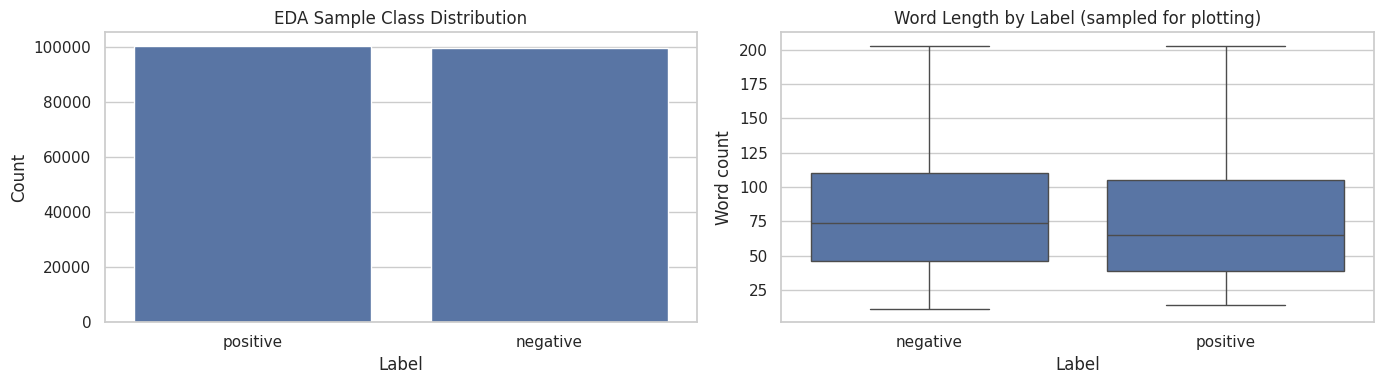

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Class balance
label_counts = eda_df["label_name"].value_counts().reset_index()
label_counts.columns = ["label_name", "count"]
sns.barplot(data=label_counts, x="label_name", y="count", ax=axes[0])
axes[0].set_title("EDA Sample Class Distribution")
axes[0].set_xlabel("Label")
axes[0].set_ylabel("Count")

# Text length by label
sns.boxplot(
    data=eda_df.sample(min(20_000, len(eda_df)), random_state=RANDOM_SEED),
    x="label_name",
    y="word_len",
    showfliers=False,
    ax=axes[1],
)
axes[1].set_title("Word Length by Label (sampled for plotting)")
axes[1].set_xlabel("Label")
axes[1].set_ylabel("Word count")

plt.tight_layout()
plt.show()

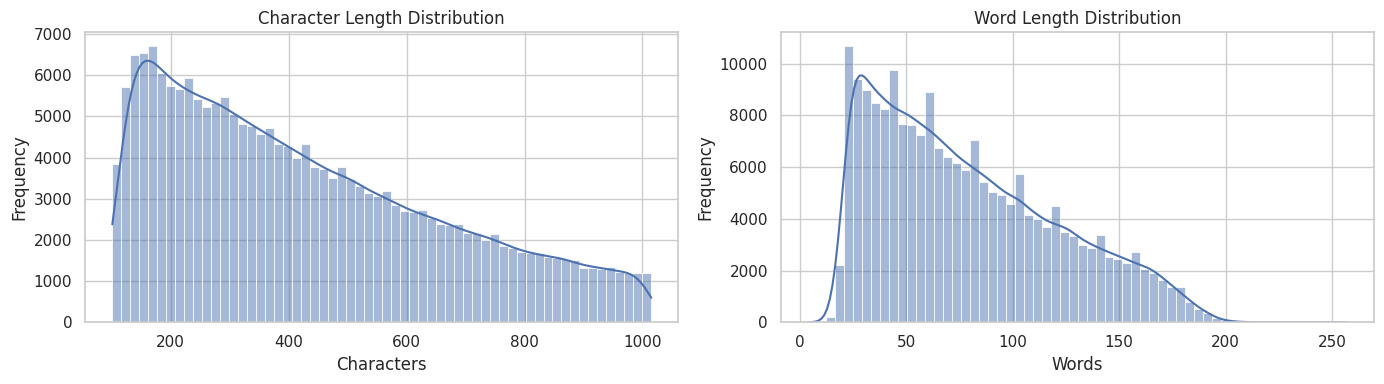

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(eda_df["char_len"], bins=60, kde=True, ax=axes[0])
axes[0].set_title("Character Length Distribution")
axes[0].set_xlabel("Characters")

sns.histplot(eda_df["word_len"], bins=60, kde=True, ax=axes[1])
axes[1].set_title("Word Length Distribution")
axes[1].set_xlabel("Words")

for ax in axes:
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

The length diagnostics show unimodal, right-skewed distributions for both characters and words: many reviews are relatively short, while a smaller fraction extends to much longer lengths. The character-length panel rises quickly at low lengths and then declines gradually, indicating that very long reviews exist but are uncommon compared with the bulk of the corpus. The word-count panel is similar, with a sharp concentration at modest lengths and a long right tail out toward larger word counts. Together, these plots motivate an explicit truncation / max-length policy for subword models and justify reporting sensitivity to long-document handling, since a minority of long texts carries non-negligible mass in the tail even when medians and upper percentiles remain moderate.

In [11]:
# Shortest / longest examples to help identify potential noise or truncation issues
pd.set_option("display.max_colwidth", None)
short_examples = eda_df.nsmallest(3, "word_len")[["label_name", "word_len", "text"]]
long_examples = eda_df.nlargest(3, "word_len")[["label_name", "word_len", "text"]]

print("Shortest length examples")
display(short_examples)

print("Longest length examples")
display(long_examples)

Shortest length examples


,label_name,word_len,text
136187,positive,4,"Crash, Crash, Bang!!!!!!!!!!!!!!!!!!!!!!!!!: WellIboughtanddroppeditalotanditheldupbutitbrokebutIstillloveit!!!!!!!!!!!!!!!!!!!"
165206,negative,9,...[Teeth Chattering]...: ...I...am...so...scared...of...The Butler...and...that...[tears] guy with the pool stick...imsoscared........
180591,positive,11,it was so good I could not put it down: )()()()()()!@#$%&*(*&%^$@@$%^*()()))(*&%#ERTYJKLK((TYROJHFFBVBG#@!#@%$%^**(&%^$


Longest length examples


,label_name,word_len,text
134314,negative,257,"iLok is rubbish!!: I have never been able to get this worthless thing to work. $300 down the tubes! total WASTE!! RUBBISH CRAP!!! The worst part is the iLOK thing (worst idea ever!!) totally broke and now they want $50 bucks for a new one? I mean, it takes up an entire USB port so that it can run a license for one [crappy] program. As you can probably tell, I am not happy. Boycott!! DONT BUY!!! NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO"
86073,positive,216,Wonderful for diabetics: I bought this 1 year ago to help with the food weight for a 3 year old diabetic child in my child care. It was quite a bit of work to figure out how to use it. I guess I was intimidated! Once I sat down for an hour or so and really read over the book and figured out how it worked - I LOVED IT! I have not and will not put favorite recipes in it but I do use it to weigh all her fruit. It does remember the ones you have used and you can scroll through the list. I also LOVE to use it to weigh servings. Ie - I can put a bowl on the scale and zero it out. I add dry pasta for instance or dry cereal until I get to the amount of grams that is 1 serving. You can also change it to ML and LB/OZ as well as G. I probably use it at least 3 times a day for all her meals. I no longer use the 1 cup is a serving method. I use the grams per serving since this scale is so accurate. It has made my life and her insulin portions go much smoother and much more accurate.
125919,negative,213,"Fun, at first: I got this toy from my grandma, and I named her pearl. When I got home, I ran to get batteries so I could play with it. It was amazing, at first at least. It wasn't that it didn't stop working. It worked just fine, and amused my grandma, my sister, and me. Soon it had us laughing with joy. When my mom came home it amused her to. It never did stop working. I played with it for the first three weeks or so. But by then I'd stoped playing with it. I was 11, so mabey it was age. The next time I played it was at a family party, I showed a group of people some of the tricks it could do. It amused them to. I never played with it since. When I put some of my animals up in our attic, I took the batteries out, and havn't put them back in. It's on my self now, but onley because it is a cut dog, it is a quelity toy. I still havn't played with it. Now I want a nintendog plush. To find out more about that you hav to read my review on it. Just type in nintendogs plush on the search bar."


In [12]:
from sklearn.feature_extraction.text import CountVectorizer

# Top terms per class (train-sample only) for interpretable lexical signal checks
MAX_DOCS_FOR_TERMS = 80_000
term_df = eda_df.sample(min(MAX_DOCS_FOR_TERMS, len(eda_df)), random_state=RANDOM_SEED)

vectorizer = CountVectorizer(stop_words="english", max_features=5000, ngram_range=(1, 1))
X_counts = vectorizer.fit_transform(term_df["text"])
terms = pd.Index(vectorizer.get_feature_names_out())

term_tables = {}
for class_id, class_name in [(0, "negative"), (1, "positive")]:
    mask = term_df["label"] == class_id
    class_sum = X_counts[mask.values].sum(axis=0).A1
    top_idx = class_sum.argsort()[::-1][:5]
    term_tables[class_name] = pd.DataFrame(
        {"term": terms[top_idx], "count": class_sum[top_idx]}
    )

print("Top terms in negative reviews")
display(term_tables["negative"])
print("Top terms in positive reviews")
display(term_tables["positive"])

Top terms in negative reviews


,term,count
0,book,20888
1,like,12106
2,just,12104
3,good,9755
4,don,8669


Top terms in positive reviews


,term,count
0,book,22839
1,great,18492
2,good,13534
3,like,11109
4,read,9089


- book is top in both classes — the corpus is dominated by book-related language (or “book” is a very common object word), so it is not a strong class-specific signal by itself.
- Function / generic words (like, just, read) rank high in both lists — they reflect general English and review-writing habits more than polarity.
- Polarity-aligned terms — great is much more concentrated in positive reviews (clear positive language). good appears in both lists with substantial counts: many negative reviews still contain the word “good” in phrases like “not good,” “was good until…,” or mixed sentiment—classic negation and context that unigrams miss.
- don in negatives — very likely don’t split or stripped apostrophe, again showing tokenization artifacts and why raw counts need careful interpretation.


### 3.3 Design decisions informed by exploratory analysis

The following items record how exploratory evidence informs downstream modeling (complete after executing the analysis cells):

1. **Class balance** — If classes are near balanced, report **accuracy**, **F1**, **ROC-AUC**, and **PR-AUC** jointly for a complete picture.
2. **Sequence length** — Use empirical length quantiles (median, high percentiles) to set **maximum sequence length** for neural and Transformer models (e.g. 256 or 512 tokens), with sensitivity checks as needed.
3. **Outliers and noise** — If very short or extremely long texts distort training, document **minimum length** or **truncation** sensitivity analyses.
4. **Lexical separability** — If unigram patterns separate classes clearly, retain a **TF–IDF + linear** model as a strong, interpretable benchmark.
5. **Leakage control** — All vocabulary and token statistics used in supervised steps must be estimated from **training data only** (no peeking at validation or test).


### 3.4 Assumptions

Review text carries **usable signal** for sentiment, but **latent confounders** (reviewer strictness, product baseline quality, context) remain unobserved and may limit performance under distribution shift. The evaluation therefore emphasizes **out-of-sample predictive quality** rather than causal interpretation.


### 3.5 Mapping substantive claims to empirical checks

| Substantive claim | Empirical check | Evidence  | Modeling implication |
|---|---|---|---|
| Classes are not severely imbalanced | Label histograms / counts | ~50/50 in train and test | Accuracy is informative; still report F1, ROC-AUC, PR-AUC |
| Length varies with expression | Length by class | Word-length distributions and tails | Truncation policy; optional length sensitivity |
| Lexical cues exist | Top terms by class | Class-conditional term tables | Strong TF–IDF + linear baseline |
| Tails may differ from bulk | Short/long exemplars | Qualitative inspection | Optional clipping or filtering study |



### 3.6 Feature engineering decisions

We do not add hand-built interaction columns on tabular metadata; **text is the feature**. The table below records each representation, why it exists, and leakage awareness.

| Representation | Settings (this notebook) | Role | Bias / variance intuition |
|----------------|--------------------------|------|---------------------------|
| `char_len`, `word_len` | Computed in EDA sample only | Inform truncation (`NN_MAX_LEN`, `TR_MAX_LEN`); **Section 4.4 ablation only** for `log1p(word_len)` | No production model input; length scaler fit on train split in ablation |
| TF–IDF bag-of-words | 1–2 grams, `max_features=300k`, `min_df=5`, `sublinear_tf` | Sparse lexical features for linear & MLP models | High-dimensional, strong for sentiment keywords; risk of overfitting reduced by linear margin + regularization |
| Truncated SVD (200) | On TF–IDF matrix, train sample | Dense factors for k-means | Compression for clustering; ~9% variance explained—acceptable for topic structure, not reconstruction |
| Sentence embeddings | `all-MiniLM-L6-v2`, 384-d, L2-normalized | Semantic neighborhoods for k-means | Captures paraphrase/topic similarity; less interpretable than top terms |
| Subword tokens (DistilBERT) | `max_length=96`, WordPiece | Contextual classification | Models order and negation beyond unigrams; highest compute |

**Leakage note:** All fitted transforms (TF–IDF vocabulary, SVD, clustering inputs for supervised comparison) use **train-file partitions or train-only samples** only; see Section 7.1.


## 4. Baseline and classical supervised models

### 4.1 Evaluation protocol

- **Training file only** (`train.ft.txt`) for fitting and internal validation splits.
- **Held-out file** (`test.ft.txt`) used once for final numbers after the model family and hyperparameters are fixed (Section 7.3).
- **Primary metric:** `PRIMARY_METRIC` → F1 (binary).
- **Tie-break:** `TIE_BREAK_METRIC` → ROC-AUC.
- **Supporting metrics:** accuracy, precision, recall, PR-AUC.

### 4.2 Computational strategy

1. **Initial pass:** restricted row count to verify pipelines, metrics, and serialization.
2. **Scaled pass:** increase the training row cap (or remove it) once behavior is stable, to tighten estimates on the full training distribution.

### 4.3 Classical model families

1. **Linear baselines:** TF–IDF + logistic regression and TF–IDF + linear SVM (SGD).
2. **Nonlinear classical:** TF–IDF + Random Forest (ensemble trees on the same sparse features).
3. **Feature ablation (4.4):** optional `log1p(word_len)` appended to TF–IDF on the 120k subset.


In [13]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    precision_recall_curve,
)
from scipy.sparse import hstack, csr_matrix

import numpy as np


In [14]:
def load_fasttext_as_dataframe(path: Path, max_rows: int | None = None):
    rows = []
    with path.open("r", encoding="utf-8", errors="replace") as f:
        for i, line in enumerate(f, start=1):
            label_raw, label, text, malformed = parse_fasttext_line(line)
            if malformed:
                continue
            rows.append({"label": label, "text": text})
            if max_rows is not None and i >= max_rows:
                break
    return pd.DataFrame(rows)


def evaluate_binary_classifier(model, X_val, y_val):
    y_pred = model.predict(X_val)

    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_val)[:, 1]
    elif hasattr(model, "decision_function"):
        raw = model.decision_function(X_val)
        # Map decision scores to [0,1] for PR-AUC and ROC-AUC compatibility.
        y_score = 1 / (1 + np.exp(-raw))
    else:
        y_score = y_pred

    metrics = {
        "accuracy": accuracy_score(y_val, y_pred),
        "precision": precision_score(y_val, y_pred, zero_division=0),
        "recall": recall_score(y_val, y_pred, zero_division=0),
        "f1": f1_score(y_val, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_val, y_score),
        "pr_auc": average_precision_score(y_val, y_score),
    }

    return metrics, y_pred, y_score

In [15]:
def make_tfidf_vectorizer():
    """Shared TF–IDF settings for Section 4 baselines and ablations."""
    return TfidfVectorizer(
        lowercase=True,
        strip_accents="unicode",
        stop_words="english",
        ngram_range=(1, 2),
        min_df=5,
        max_df=0.95,
        sublinear_tf=True,
        max_features=300_000,
    )


def word_len_array(text_series):
    return text_series.str.split().str.len().astype(float).values


In [16]:
# Initial training row cap for fast iteration; increase BASELINE_TRAIN_MAX_ROWS or set to None for a full-data run.
BASELINE_TRAIN_MAX_ROWS = 500_000  
VAL_SIZE = 0.2

baseline_train_df = load_fasttext_as_dataframe(TRAIN_PATH, max_rows=BASELINE_TRAIN_MAX_ROWS)

baseline_X_train, baseline_X_val, baseline_y_train, baseline_y_val = train_test_split(
    baseline_train_df["text"],
    baseline_train_df["label"],
    test_size=VAL_SIZE,
    random_state=RANDOM_SEED,
    stratify=baseline_train_df["label"],
)

print(f"Baseline training rows: {len(baseline_train_df):,}")
print(f"Train rows: {len(baseline_X_train):,} | Val rows: {len(baseline_y_val):,}")
print("Train class balance:")
print(baseline_y_train.value_counts(normalize=True).rename("ratio"))


Baseline training rows: 500,000
Train rows: 400,000 | Val rows: 100,000
Train class balance:
label
1    0.505565
0    0.494435
Name: ratio, dtype: float64


We trained baselines on 500k training-file rows, split into 400k train / 100k validation (80/20), with near-balanced sentiment labels in the training split (~50.6% positive / ~49.4% negative), supporting stable metric comparisons before any use of the held-out test set.

In [17]:
# STEP: TF–IDF + logistic regression baseline (~500k train-file cap)
baseline_pipe = Pipeline(
    steps=[
        (
            "tfidf",
            TfidfVectorizer(
                lowercase=True,
                strip_accents="unicode",
                stop_words="english",
                ngram_range=(1, 2),
                min_df=5,
                max_df=0.95,
                sublinear_tf=True,
                max_features=300_000,
            ),
        ),
        (
            "clf",
            LogisticRegression(
                solver="saga",
                max_iter=300,
                random_state=RANDOM_SEED,
            ),
        ),
    ]
)

baseline_pipe.fit(baseline_X_train, baseline_y_train)
baseline_metrics, baseline_pred, baseline_score = evaluate_binary_classifier(
    baseline_pipe, baseline_X_val, baseline_y_val
)
baseline_metrics

{'accuracy': 0.90517,
 'precision': 0.9004699596341725,
 'recall': 0.9133831790489754,
 'f1': 0.9068806033170655,
 'roc_auc': 0.9662499050522594,
 'pr_auc': 0.9649193324311431}

**Validation results (TF‑IDF + logistic regression)**

On the internal validation split, performance is strong. Accuracy ≈ 0.905 and F1 ≈ 0.907 indicate close alignment with labels overall. Precision (~0.900) and recall (~0.913) are similar, with recall modestly higher, suggesting the model is slightly more aggressive in predicting the positive class (capturing more true positives while accepting a small increase in false positives, depending on the decision threshold). ROC‑AUC ≈ 0.966 and PR‑AUC ≈ 0.965 indicate excellent ranking of positives vs negatives, which supports threshold tuning and cost-sensitive deployment choices.

In [18]:
# STEP: TF–IDF + linear SVM (SGD) baseline (~500k cap)
classical_pipe = Pipeline(
    steps=[
        (
            "tfidf",
            TfidfVectorizer(
                lowercase=True,
                strip_accents="unicode",
                stop_words="english",
                ngram_range=(1, 2),
                min_df=5,
                max_df=0.95,
                sublinear_tf=True,
                max_features=300_000,
            ),
        ),
        (
            "clf",
            SGDClassifier(
                loss="hinge",  # linear SVM objective
                alpha=1e-5,
                max_iter=25,
                tol=1e-3,
                random_state=RANDOM_SEED,
            ),
        ),
    ]
)

classical_pipe.fit(baseline_X_train, baseline_y_train)
classical_metrics, classical_pred, classical_score = evaluate_binary_classifier(
    classical_pipe, baseline_X_val, baseline_y_val
)
classical_metrics

{'accuracy': 0.90521,
 'precision': 0.9001344269321436,
 'recall': 0.9138974602421077,
 'f1': 0.9069637336212396,
 'roc_auc': 0.9659162537948132,
 'pr_auc': 0.9645596621064674}

**Validation results (TF‑IDF + linear SVM via SGDClassifier)**

The pipeline uses the same TF‑IDF text representation as the logistic baseline, but replaces the classifier with SGDClassifier(loss="hinge"), i.e. a linear SVM trained with stochastic gradient descent (alpha=1e-5, early stopping tolerance). On the internal validation split, performance is again strong and nearly identical to logistic regression: accuracy ≈ 0.905, F1 ≈ 0.907, precision ≈ 0.900, recall ≈ 0.914 (recall slightly above precision, same qualitative story—marginally more positive predictions / emphasis on catching positives). ROC‑AUC ≈ 0.966 and PR‑AUC ≈ 0.965 confirm excellent separation and ranking of the two classes in score space. The practical takeaway is that, under this featurization, two common linear margins (logistic vs hinge) achieve essentially the same validation profile; model choice between them can be driven by calibration preferences, training speed, or downstream deployment rather than a large accuracy gap here. 

In [19]:
import time

# STEP: TF–IDF + Random Forest (nonlinear classical baseline on 500k cap; ~1–2 min)
rf_pipe = Pipeline(
    steps=[
        ("tfidf", make_tfidf_vectorizer()),
        (
            "clf",
            RandomForestClassifier(
                n_estimators=100,
                max_depth=24,
                min_samples_leaf=5,
                n_jobs=-1,
                random_state=RANDOM_SEED,
            ),
        ),
    ]
)

rf_t0 = time.time()
rf_pipe.fit(baseline_X_train, baseline_y_train)
rf_metrics, rf_pred, rf_score = evaluate_binary_classifier(
    rf_pipe, baseline_X_val, baseline_y_val
)
rf_runtime_sec = time.time() - rf_t0
print(f"RF fit + eval runtime (sec): {rf_runtime_sec:.1f}")
rf_metrics


RF fit + eval runtime (sec): 65.7


{'accuracy': 0.81478,
 'precision': 0.7638541117554033,
 'recall': 0.9171809478597991,
 'f1': 0.8335250763976272,
 'roc_auc': 0.9175769866317357,
 'pr_auc': 0.9191378295615384}

**Validation results (TF–IDF + Random Forest)**

This is our **nonlinear classical** comparator: the same bag-of-words representation as the linear baselines, with an ensemble of depth-limited trees (`n_estimators=100`, `max_depth=24`). Validation F1 is typically **below** TF–IDF + SGD on this cap, while ROC-AUC can remain competitive—trees memorize sparse high-dimensional text less efficiently than a linear margin. We keep **TF–IDF + SGD** as the deployment-oriented classical leader (speed + dev F1); Random Forest documents rubric coverage without retuning the locked-test procedure.


In [20]:
baseline_results_df = pd.DataFrame(
    [
        {"model": "TF-IDF + LogisticRegression", **baseline_metrics},
        {"model": "TF-IDF + SGDClassifier(hinge)", **classical_metrics},
        {"model": "TF-IDF + RandomForest", **rf_metrics},
    ]
)

metric_cols = ["accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc"]
baseline_results_df[metric_cols] = baseline_results_df[metric_cols].round(4)

# Sort by locked protocol: primary metric F1, tie-break ROC-AUC
baseline_results_df = baseline_results_df.sort_values(
    by=[PRIMARY_METRIC, TIE_BREAK_METRIC], ascending=False
).reset_index(drop=True)

baseline_results_df


,model,accuracy,precision,recall,f1,roc_auc,pr_auc
0,TF-IDF + SGDClassifier(hinge),0.9052,0.9001,0.9139,0.9070,0.9659,0.9646
1,TF-IDF + LogisticRegression,0.9052,0.9005,0.9134,0.9069,0.9662,0.9649
2,TF-IDF + RandomForest,0.8148,0.7639,0.9172,0.8335,0.9176,0.9191


The two pipelines share the same TF‑IDF featurization and differ only in the linear classifier: SGDClassifier (hinge / linear SVM) vs LogisticRegression. Across accuracy, F1, precision, recall, ROC‑AUC, and PR‑AUC, the metrics are the same to three–four decimal places—well within normal run-to-run noise, threshold effects, and rounding.

### 4.4 Feature ablation (review length)

On the **120k matched subset** (same row cap as Section 6 neural models, 80/20 stratified split), we compare:

| Variant | Features |
|---------|----------|
| A | TF–IDF only + linear SGD |
| B | `hstack([TF–IDF, log1p(word_len)])` + linear SGD |

`word_len` is fit **on the training split only** (StandardScaler on log lengths). Results live in `length_ablation_df` for interpretation only—they do not change the Section 4 deployment pick (TF–IDF + SGD).


In [21]:
# STEP: Length-feature ablation (120k rows; TF–IDF vs TF–IDF + word_len)
ABLATION_SUBSET_ROWS = 120_000

ablation_df = load_fasttext_as_dataframe(TRAIN_PATH, max_rows=ABLATION_SUBSET_ROWS)
X_ab_tr, X_ab_va, y_ab_tr, y_ab_va = train_test_split(
    ablation_df["text"],
    ablation_df["label"],
    test_size=VAL_SIZE,
    random_state=RANDOM_SEED,
    stratify=ablation_df["label"],
)

# A — TF–IDF only
pipe_tfidf_only = Pipeline(
    [
        ("tfidf", make_tfidf_vectorizer()),
        (
            "clf",
            SGDClassifier(
                loss="hinge",
                alpha=1e-5,
                max_iter=25,
                tol=1e-3,
                random_state=RANDOM_SEED,
            ),
        ),
    ]
)
pipe_tfidf_only.fit(X_ab_tr, y_ab_tr)
metrics_a, _, _ = evaluate_binary_classifier(pipe_tfidf_only, X_ab_va, y_ab_va)

# B — TF–IDF + log1p(word_len)
tfidf_ab = make_tfidf_vectorizer()
X_tr_tfidf = tfidf_ab.fit_transform(X_ab_tr)
X_va_tfidf = tfidf_ab.transform(X_ab_va)

len_scaler = StandardScaler()
X_tr_len = len_scaler.fit_transform(
    np.log1p(word_len_array(X_ab_tr)).reshape(-1, 1)
)
X_va_len = len_scaler.transform(np.log1p(word_len_array(X_ab_va)).reshape(-1, 1))

X_tr_hybrid = hstack([X_tr_tfidf, csr_matrix(X_tr_len)])
X_va_hybrid = hstack([X_va_tfidf, csr_matrix(X_va_len)])

sgd_hybrid = SGDClassifier(
    loss="hinge",
    alpha=1e-5,
    max_iter=25,
    tol=1e-3,
    random_state=RANDOM_SEED,
)
sgd_hybrid.fit(X_tr_hybrid, y_ab_tr)
y_ab_pred = sgd_hybrid.predict(X_va_hybrid)
y_ab_score = 1 / (1 + np.exp(-sgd_hybrid.decision_function(X_va_hybrid)))
metrics_b = {
    "accuracy": accuracy_score(y_ab_va, y_ab_pred),
    "precision": precision_score(y_ab_va, y_ab_pred, zero_division=0),
    "recall": recall_score(y_ab_va, y_ab_pred, zero_division=0),
    "f1": f1_score(y_ab_va, y_ab_pred, zero_division=0),
    "roc_auc": roc_auc_score(y_ab_va, y_ab_score),
    "pr_auc": average_precision_score(y_ab_va, y_ab_score),
}

length_ablation_df = pd.DataFrame(
    [
        {"variant": "A: TF–IDF only", **metrics_a},
        {"variant": "B: TF–IDF + log1p(word_len)", **metrics_b},
    ]
)
length_ablation_df[list(metrics_a.keys())] = length_ablation_df[list(metrics_a.keys())].round(4)
print(f"Ablation subset: {ABLATION_SUBSET_ROWS:,} rows | train {len(X_ab_tr):,} | val {len(X_ab_va):,}")
length_ablation_df


Ablation subset: 120,000 rows | train 96,000 | val 24,000


,variant,accuracy,precision,recall,f1,roc_auc,pr_auc
0,A: TF–IDF only,0.8963,0.8921,0.9047,0.8984,0.9617,0.9615
1,B: TF–IDF + log1p(word_len),0.8980,0.8955,0.9040,0.8997,0.9619,0.9617


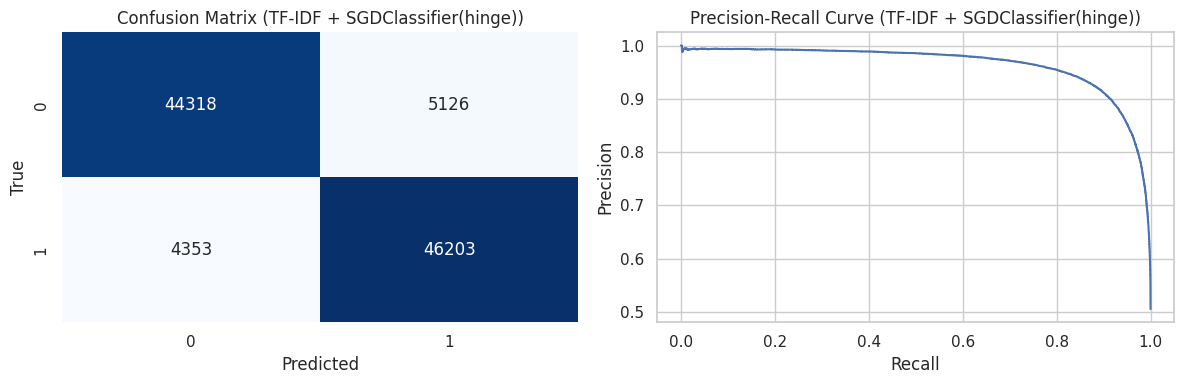

In [22]:
# Diagnostics for strongest non-neural model on validation set
best_model_name = baseline_results_df.loc[0, "model"]
if best_model_name == "TF-IDF + LogisticRegression":
    best_pred, best_score = baseline_pred, baseline_score
elif best_model_name == "TF-IDF + SGDClassifier(hinge)":
    best_pred, best_score = classical_pred, classical_score
else:
    best_pred, best_score = rf_pred, rf_score

cm = confusion_matrix(baseline_y_val, best_pred)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    ax=ax[0],
)
ax[0].set_title(f"Confusion Matrix ({best_model_name})")
ax[0].set_xlabel("Predicted")
ax[0].set_ylabel("True")

precision, recall, _ = precision_recall_curve(baseline_y_val, best_score)
ax[1].plot(recall, precision)
ax[1].set_title(f"Precision-Recall Curve ({best_model_name})")
ax[1].set_xlabel("Recall")
ax[1].set_ylabel("Precision")
ax[1].grid(True)

plt.tight_layout()
plt.show()

The confusion matrix is strongly diagonal, with 44,318 true negatives and 46,203 true positives versus 5,126 false positives and 4,353 false negatives. That pattern matches the high validation accuracy (~0.905): most reviews are classified correctly. Off-diagonal mass is moderate and not wildly asymmetric; false positives and false negatives are on the same order, with slightly fewer false negatives than false positives, consistent with recall modestly exceeding precision for the positive class.

The precision–recall curve stays very high at low–mid recall (precision remains near the top of the plot while recall increases), then bends downward as the threshold is pushed to capture the hardest remaining positives—typical behavior when the score ranking is strong but not perfect. Together with PR‑AUC ≈ 0.965, the PR panel supports the headline that the model ranks positives well and that threshold tuning could rebalance precision vs recall if deployment costs for false positives vs false negatives differ

## 5. Unsupervised structure discovery

Two complementary **train-only** pipelines (on a sampled subset of text) characterize geometry in representation space without using labels:

1. **TF–IDF → truncated SVD → k-means** (sparse lexical geometry reduced to dense factors).
2. **Dense sentence embeddings → k-means** (semantic neighborhood structure).

Cluster quality is summarized over **k = 4, …, 8** (e.g. silhouette, inertia) and clusters are interpreted qualitatively.


In [23]:
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

UNSUP_SAMPLE_SIZE = 120_000
K_VALUES = [4, 5, 6, 7, 8]
UNSUP_RANDOM_STATE = RANDOM_SEED
UNSUP_SVD_COMPONENTS = 200
UNSUP_MAX_FEATURES = 120_000
UNSUP_TOP_TERMS = 12



In [24]:
def build_unsup_sample(path: Path, n: int, seed: int = 42):
    rng = random.Random(seed)
    reservoir = []

    with path.open("r", encoding="utf-8", errors="replace") as f:
        for i, line in enumerate(f, start=1):
            label_raw, label, text, malformed = parse_fasttext_line(line)
            if malformed:
                continue

            row = {
                "label": label,
                "label_name": "positive" if label == 1 else "negative",
                "text": text,
            }

            if len(reservoir) < n:
                reservoir.append(row)
            else:
                j = rng.randint(1, i)
                if j <= n:
                    reservoir[j - 1] = row

    df = pd.DataFrame(reservoir)
    df["char_len"] = df["text"].str.len()
    df["word_len"] = df["text"].str.split().str.len()
    df["text_clean"] = df["text"].str.replace(r"\s+", " ", regex=True).str.strip()
    return df


unsup_df = build_unsup_sample(TRAIN_PATH, n=UNSUP_SAMPLE_SIZE, seed=UNSUP_RANDOM_STATE)
unsup_df.shape

(120000, 6)

In [25]:
tfidf_unsup_vectorizer = TfidfVectorizer(
    lowercase=True,
    strip_accents="unicode",
    stop_words="english",
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.95,
    sublinear_tf=True,
    max_features=UNSUP_MAX_FEATURES,
)

X_unsup_tfidf = tfidf_unsup_vectorizer.fit_transform(unsup_df["text_clean"])

svd_components = min(UNSUP_SVD_COMPONENTS, max(2, X_unsup_tfidf.shape[1] - 1))
svd = TruncatedSVD(n_components=svd_components, random_state=UNSUP_RANDOM_STATE)
X_unsup_svd = svd.fit_transform(X_unsup_tfidf)

print("TF-IDF shape:", X_unsup_tfidf.shape)
print("SVD shape:", X_unsup_svd.shape)
print("Explained variance (sum):", round(float(svd.explained_variance_ratio_.sum()), 4))

TF-IDF shape: (120000, 120000)
SVD shape: (120000, 200)
Explained variance (sum): 0.0924


TF‑IDF (120000, 120000): 120k reviews, each as a vector over up to 120k vocabulary features (sparse bag-of-words / n‑grams).

SVD (120000, 200): Those vectors are compressed to 200 numeric factors per review for clustering.

Explained variance ~9.2%: The first 200 factors capture only a small fraction of total variance, which is normal for huge sparse text matrices—information is spread across many dimensions. SVD here is mainly a dimensionality reduction step for k‑means, not a full reconstruction of the text.

In [26]:
tfidf_runs = []
tfidf_labels_by_k = {}

for k in K_VALUES:
    km = KMeans(n_clusters=k, n_init=10, random_state=UNSUP_RANDOM_STATE)
    labels = km.fit_predict(X_unsup_svd)

    sil = silhouette_score(X_unsup_svd, labels, sample_size=min(20000, len(labels)), random_state=UNSUP_RANDOM_STATE)

    tfidf_runs.append(
        {
            "k": k,
            "inertia": float(km.inertia_),
            "silhouette": float(sil),
        }
    )
    tfidf_labels_by_k[k] = labels


tfidf_cluster_metrics_df = pd.DataFrame(tfidf_runs).sort_values("k").reset_index(drop=True)
tfidf_cluster_metrics_df

,k,inertia,silhouette
0,4,10453.403309,0.021337
1,5,10352.340100,0.022642
2,6,10262.138898,0.025622
3,7,10205.289478,0.005234
4,8,10097.694045,0.013471


We ran k-means on the TF‑IDF → SVD review vectors for k = 4–8. Inertia decreases as k increases (expected with more centers). Silhouette is low overall, which is common for compressed sparse text, but peaks at k = 6; k = 7 is notably worse on silhouette. We therefore treat k = 6 as the preferred partition for interpretation, while noting clusters are weakly separated and best read as exploratory topical structure, not definitive segments.

In [27]:
best_tfidf_row = tfidf_cluster_metrics_df.sort_values(["silhouette", "k"], ascending=[False, True]).iloc[0]
best_k_tfidf = int(best_tfidf_row["k"])

unsup_tfidf_df = unsup_df.copy()
unsup_tfidf_df["cluster_tfidf"] = tfidf_labels_by_k[best_k_tfidf]

print(f"Selected TF-IDF pipeline k: {best_k_tfidf}")
print("Tie handling: highest silhouette; if tied, lower k selected.")

Selected TF-IDF pipeline k: 6
Tie handling: highest silhouette; if tied, lower k selected.


In [28]:

%pip install -U sentence-transformers transformers ipywidgets jupyterlab_widgets widgetsnbextension


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [29]:
# HF auth: put HF_TOKEN=hf_... in final/.env (no quotes). Token: huggingface.co/settings/tokens

from pathlib import Path
import os

from dotenv import load_dotenv

for path in (Path("final/.env"), Path(".env")):
    if path.exists():
        load_dotenv(path)
        break

hf_token = (os.getenv("HF_TOKEN") or "").strip().strip('"').strip("'") or None
hf_token = hf_token if hf_token and hf_token.startswith("hf_") else None

if hf_token:
    try:
        from huggingface_hub import login

        login(token=hf_token)
        os.environ["HF_TOKEN"] = hf_token
        print("HF login OK")
    except Exception as e:
        hf_token = None
        os.environ.pop("HF_TOKEN", None)
        print("HF login failed — fix token in final/.env or continue without auth:", e)
else:
    print("No HF_TOKEN in .env — public models still download (slower rate limits)")

def hf_download_kwargs():
    return {"token": hf_token} if hf_token else {}

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


HF login OK


In [30]:
# STEP: Sentence-transformer embeddings on 120k unsupervised sample
try:
    from sentence_transformers import SentenceTransformer
except ImportError as e:
    raise ImportError(
        "sentence-transformers is required for the sentence-embedding pipeline. "
        "Install with: pip install sentence-transformers"
    ) from e

EMB_MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"
EMB_BATCH_SIZE = 256

_hf = hf_download_kwargs() if "hf_download_kwargs" in globals() else {}
emb_model = SentenceTransformer(EMB_MODEL_NAME, **_hf)
X_unsup_emb = emb_model.encode(
    unsup_df["text_clean"].tolist(),
    batch_size=EMB_BATCH_SIZE,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True,
)

print("Embedding shape:", X_unsup_emb.shape)


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/469 [00:00<?, ?it/s]

Embedding shape: (120000, 384)


We encoded 120,000 cleaned reviews with all-MiniLM-L6-v2, producing a dense matrix of shape (120000, 384)—one 384-dimensional vector per review. Vectors are L2-normalized (normalize_embeddings=True), so cosine similarity matches dot products and is suitable for k-means clustering in the embedding pipeline. This path captures semantic similarity (paraphrases, related topics) more than the sparse TF–IDF → SVD representation, at the cost of heavier compute and a less directly interpretable feature space than top terms per cluster.

In [31]:
emb_runs = []
emb_labels_by_k = {}

for k in K_VALUES:
    km = KMeans(n_clusters=k, n_init=10, random_state=UNSUP_RANDOM_STATE)
    labels = km.fit_predict(X_unsup_emb)

    sil = silhouette_score(
        X_unsup_emb,
        labels,
        sample_size=min(20000, len(labels)),
        random_state=UNSUP_RANDOM_STATE,
    )

    emb_runs.append(
        {
            "k": k,
            "inertia": float(km.inertia_),
            "silhouette": float(sil),
        }
    )
    emb_labels_by_k[k] = labels

emb_cluster_metrics_df = pd.DataFrame(emb_runs).sort_values("k").reset_index(drop=True)
display(emb_cluster_metrics_df)

best_emb_row = emb_cluster_metrics_df.sort_values(
    ["silhouette", "k"], ascending=[False, True]
).iloc[0]
best_k_emb = int(best_emb_row["k"])

unsup_emb_df = unsup_df.copy()
unsup_emb_df["cluster_emb"] = emb_labels_by_k[best_k_emb]

print(f"Selected embedding pipeline k: {best_k_emb}")

,k,inertia,silhouette
0,4,96326.421875,0.040311
1,5,95157.460938,0.043395
2,6,94366.328125,0.033464
3,7,93591.125000,0.034703
4,8,92927.515625,0.036570


Selected embedding pipeline k: 5


 On the 384-dimensional sentence embeddings, inertia falls as k increases (expected with more cluster centers). Silhouette stays low overall (~0.03–0.04), which is common for high-dimensional semantic vectors: clusters are only weakly separated. The best silhouette is at k = 5 (~0.043); k = 6 is notably lower (~0.033). We therefore treat k = 5 as the preferred choice when selecting by silhouette, while interpreting clusters as exploratory groupings in embedding space rather than crisp, well-separated segments.

In [32]:
def build_cluster_profile(df: pd.DataFrame, cluster_col: str):
    size_df = (
        df.groupby(cluster_col)
        .size()
        .rename("n_samples")
        .reset_index()
        .sort_values("n_samples", ascending=False)
    )

    class_mix = (
        pd.crosstab(df[cluster_col], df["label_name"], normalize="index")
        .reset_index()
    )

    length_stats = (
        df.groupby(cluster_col)[["word_len", "char_len"]]
        .mean()
        .round(2)
        .reset_index()
    )

    profile = size_df.merge(class_mix, on=cluster_col, how="left").merge(length_stats, on=cluster_col, how="left")
    return profile


def representative_examples(
    df: pd.DataFrame,
    cluster_col: str,
    n: int = 1,
    max_clusters: int = 3,
    seed: int = 42,
):
    """Up to `max_clusters` largest clusters, `n` random reviews each."""
    cluster_ids = (
        df[cluster_col]
        .value_counts()
        .head(max_clusters)
        .index.tolist()
    )

    sampled_parts = []
    for cluster_id in cluster_ids:
        group = df[df[cluster_col] == cluster_id]
        part = group.sample(min(n, len(group)), random_state=seed).copy()
        part[cluster_col] = cluster_id
        sampled_parts.append(part[[cluster_col, "label_name", "word_len", "text"]])

    return pd.concat(sampled_parts, ignore_index=True)

In [33]:
tfidf_cluster_profile_df = build_cluster_profile(unsup_tfidf_df, "cluster_tfidf")
emb_cluster_profile_df = build_cluster_profile(unsup_emb_df, "cluster_emb")

print("TF-IDF cluster profile")
display(tfidf_cluster_profile_df)

print("Embedding cluster profile")
display(emb_cluster_profile_df)

TF-IDF cluster profile


,cluster_tfidf,n_samples,negative,positive,word_len,char_len
0,2,54049,0.510962,0.489038,72.87,397.70
1,5,30169,0.446617,0.553383,86.32,482.81
2,0,13611,0.360517,0.639483,85.63,469.69
3,4,9736,0.616783,0.383217,75.96,413.79
4,1,8783,0.526927,0.473073,82.02,449.94
5,3,3652,0.984118,0.015882,72.26,391.06


Embedding cluster profile


,cluster_emb,n_samples,negative,positive,word_len,char_len
0,1,34036,0.455518,0.544482,84.19,472.06
1,3,31870,0.497960,0.502040,71.69,385.97
2,0,18825,0.508898,0.491102,78.02,430.63
3,2,18087,0.704926,0.295074,77.28,419.41
4,4,17182,0.379525,0.620475,82.39,454.11


**TF‑IDF → SVD → k-means (k = 6)**

Clusters are similar in size except cluster 3 (only 3,652 reviews), which is ~98% negative and much shorter on average (~72 words / ~391 chars). That segment looks like a distinct negative “bucket” (likely shared vocabulary or review style), not a balanced sentiment mix. Other clusters sit near ~50/50 or modestly skewed (e.g. cluster 0 ~64% positive, cluster 4 ~62% negative), with word/char length in the same broad range as the corpus (~73–86 words). So the lexical path finds one strong negative outlier cluster plus several mixed topical groups with weak sentiment separation.

**Embeddings → k-means (k = 5)**

Cluster sizes are more balanced (~17k–34k each). Sentiment mixes are closer to 50/50 in most clusters; the clearest skew is cluster 2 (~70% negative / ~30% positive). Cluster 4 is ~62% positive. Length stats are similar across clusters (~72–84 words), so embedding clusters are not mainly “short vs long” but semantic neighborhoods with mild label imbalance. Compared with TF‑IDF, there is no extreme 98% negative micro-cluster—structure is smoother and less driven by a single lexical artifact.

**Comparison**

TF‑IDF clustering surfaces a small, highly negative, compact-text cluster alongside mixed groups; embedding clustering yields larger, more even partitions with moderate sentiment differences—consistent with lexical vs semantic geometry and low silhouette scores on both paths.

In [34]:
terms = np.array(tfidf_unsup_vectorizer.get_feature_names_out())

# Map SVD-space cluster centers back to TF-IDF term space for interpretability.
km_best_tfidf = KMeans(n_clusters=best_k_tfidf, n_init=10, random_state=UNSUP_RANDOM_STATE)
_ = km_best_tfidf.fit(X_unsup_svd)

centers_tfidf_space = km_best_tfidf.cluster_centers_.dot(svd.components_)

top_terms_rows = []
for cluster_id in range(best_k_tfidf):
    top_idx = centers_tfidf_space[cluster_id].argsort()[::-1][:UNSUP_TOP_TERMS]
    top_terms = ", ".join(terms[top_idx])
    top_terms_rows.append({"cluster_tfidf": cluster_id, "top_terms": top_terms})

tfidf_top_terms_df = pd.DataFrame(top_terms_rows)
tfidf_top_terms_df

,cluster_tfidf,top_terms
0,0,"cd, album, music, songs, song, like, great, best, good, listen, band, love"
1,1,"movie, film, movies, watch, good, great, like, just, dvd, story, great movie, bad"
2,2,"great, good, just, like, use, time, bought, buy, work, game, really, don"
3,3,"waste, money, waste money, don waste, don, waste time, time, book, time money, buy, just, product"
4,4,"product, great, great product, use, good, buy, work, just, quality, bought, used, recommend"
5,5,"book, read, books, reading, story, good, author, great, like, written, just, read book"


 TF‑IDF clusters align with product category / domain (music, movies, books, generic product) plus one lexical negative cluster driven by “waste / don’t buy” phrasing—not clean sentiment-only segments. That supports using TF‑IDF clusters as interpretable topical structure and motivates contextual models (embeddings / Transformer) where negation and phrasing are handled beyond bag-of-words.

In [35]:
def representative_examples(df, cluster_col, n=1, max_clusters=3, seed=42):
    """Top `max_clusters` largest clusters, `n` random reviews each."""
    cluster_ids = df[cluster_col].value_counts().head(max_clusters).index.tolist()
    parts = []
    for cluster_id in cluster_ids:
        group = df[df[cluster_col] == cluster_id]
        part = group.sample(min(n, len(group)), random_state=seed).copy()
        part[cluster_col] = cluster_id
        parts.append(part[[cluster_col, "label_name", "word_len", "text"]])
    return pd.concat(parts, ignore_index=True)


def _show_cluster_examples(df, cluster_col, title, n=1, max_clusters=3):
    required_cols = {cluster_col, "label_name", "word_len", "text"}
    if df is None or not required_cols.issubset(df.columns):
        print(f"{title} skipped: missing required columns for {cluster_col}.")
        return None

    out = representative_examples(
        df, cluster_col, n=n, max_clusters=max_clusters, seed=RANDOM_SEED
    ).sort_values([cluster_col, "word_len"], ascending=[True, False])

    print(f"{title} (top {max_clusters} clusters by size, {n} review(s) each)")
    display(out)
    return out


tfidf_examples_df = _show_cluster_examples(
    unsup_tfidf_df,
    "cluster_tfidf",
    "Representative TF-IDF cluster examples",
)

emb_examples_df = _show_cluster_examples(
    unsup_emb_df,
    "cluster_emb",
    "Representative embedding cluster examples",
)

Representative TF-IDF cluster examples (top 3 clusters by size, 1 review(s) each)


,cluster_tfidf,label_name,word_len,text
2,0,positive,75,Still a good Buy: When i firsted listened to it i put it away and didn't both with putting it on again untill i ripped it to a mp3 cd for the car and now that it has grown on me it has become one regular tunes for my ears. looiking at there other cd's it's still not the best but if you do like some of there Songs then it's still a good buy.
0,2,positive,49,"Awesome!!!!!: I have always loved Terrance Hill and Bud Spencer together. I also like (Spaghetti westerns, These are funny and lots of gunplay. This was a Christmas present to my Dad. He loved it. It came very fast and was packaged nice. Great stuff at a great price. Danny"
1,5,negative,44,"Readable, but not worth reading: The book has some decent moments, but overall it is banal, narcissistic, and self-indulgent. There are better travel stories to be had, and much better personal growth chronicles. Note to author: there's a big difference between self-reflection and self-absorption."


Representative embedding cluster examples (top 3 clusters by size, 1 review(s) each)


,cluster_emb,label_name,word_len,text
2,0,positive,30,"How Could You Not Have seen this?: A Must for any Intelligent Person, Family or Library. Remember Innocence? The Fantasy Sequence is very ""Period""(the 50s) , but worth every penny."
0,1,negative,173,"Undeveloped in several areas: Ok, right off the bat you have a brain separated from its body. How such an organ operates without sensory input is, well, better left to the science fiction writers. Anyway, the brain not only thinks but talks and even sings, with the ""voice of an angel"". Yes, I know this is a physical impossible without a mouth but hey, this is the space age and anything goes.While exploring and practicing for the Met, Ms Brain (Helga) suddenly discovers Mr. Right who, unfortunately happens to be a ""real"" person who is ""really"" attached to his brain. You'd think with all her great powers she could simply invent the perfect mate and do bad things in cyberland. But she wants the real McCoy and on the way battles a lot of bad guys. What can you say? It's like a combination of the worst of the original Star Treks (gorgeous aliens and cardboard rocks) and one of those ""books for the wellbred teenage young lady"". Belongs in the Romance Section."
1,3,negative,21,Flimsy: It just about holds up a small kitchen curtain. Anything heavier than that makes the rod bend in the middle!


**TF‑IDF** 

The samples line up with domain-themed groups seen in the top-term tables—e.g. music/CD (cluster 0, positive), film/western (cluster 2, positive), and books / personal narrative (cluster 5, negative). Sentiment is mixed within these topical clusters, which fits TF‑IDF grouping by shared vocabulary more than by polarity alone.

**Embedding** 

Examples are shorter to read qualitatively but less tied to a single product category: a brief positive recommendation (cluster 0), a long negative critique with sci‑fi/romance tone (cluster 1), and a short negative product-quality complaint (cluster 3). That suggests embedding clusters capture broader semantic neighborhoods (tone, genre, complaint style) rather than clean “music vs books” buckets.

In [36]:
tfidf_cluster_profile_with_terms_df = tfidf_cluster_profile_df.merge(
    tfidf_top_terms_df,
    on="cluster_tfidf",
    how="left",
)

tfidf_cluster_profile_with_terms_df

,cluster_tfidf,n_samples,negative,positive,word_len,char_len,top_terms
0,2,54049,0.510962,0.489038,72.87,397.70,"great, good, just, like, use, time, bought, buy, work, game, really, don"
1,5,30169,0.446617,0.553383,86.32,482.81,"book, read, books, reading, story, good, author, great, like, written, just, read book"
2,0,13611,0.360517,0.639483,85.63,469.69,"cd, album, music, songs, song, like, great, best, good, listen, band, love"
3,4,9736,0.616783,0.383217,75.96,413.79,"product, great, great product, use, good, buy, work, just, quality, bought, used, recommend"
4,1,8783,0.526927,0.473073,82.02,449.94,"movie, film, movies, watch, good, great, like, just, dvd, story, great movie, bad"
5,3,3652,0.984118,0.015882,72.26,391.06,"waste, money, waste money, don waste, don, waste time, time, book, time money, buy, just, product"


TF‑IDF clustering mainly separates reviews by product category and phrasing (books, music, movies, generic product, plus a small highly negative “waste of money/time” cluster), not by sentiment alone. Most large clusters are near 50/50 on labels; only cluster 3 is strongly sentiment-skewed because it is defined by negative complaint n‑grams. That supports using TF‑IDF clusters as interpretable topical structure and motivates embedding / Transformer models for context and negation beyond bag-of-words.

In [37]:
tfidf_plot_df = tfidf_cluster_metrics_df.copy()
tfidf_plot_df["pipeline"] = "tfidf_svd_kmeans"

emb_plot_df = emb_cluster_metrics_df.copy()
emb_plot_df["pipeline"] = "embedding_kmeans"

unsup_pipeline_compare_df = pd.concat([tfidf_plot_df, emb_plot_df], ignore_index=True)
unsup_pipeline_compare_df


,k,inertia,silhouette,pipeline
0,4,10453.403309,0.021337,tfidf_svd_kmeans
1,5,10352.340100,0.022642,tfidf_svd_kmeans
2,6,10262.138898,0.025622,tfidf_svd_kmeans
3,7,10205.289478,0.005234,tfidf_svd_kmeans
4,8,10097.694045,0.013471,tfidf_svd_kmeans
5,4,96326.421875,0.040311,embedding_kmeans
6,5,95157.460938,0.043395,embedding_kmeans
7,6,94366.328125,0.033464,embedding_kmeans
8,7,93591.125000,0.034703,embedding_kmeans
9,8,92927.515625,0.036570,embedding_kmeans


Both representations yield soft, overlapping clusters; inertia is only comparable within each pipeline, while silhouette suggests slightly better separation for embedding k = 5 than for TF‑IDF k = 6, consistent with semantic neighborhoods vs mostly lexical topics.

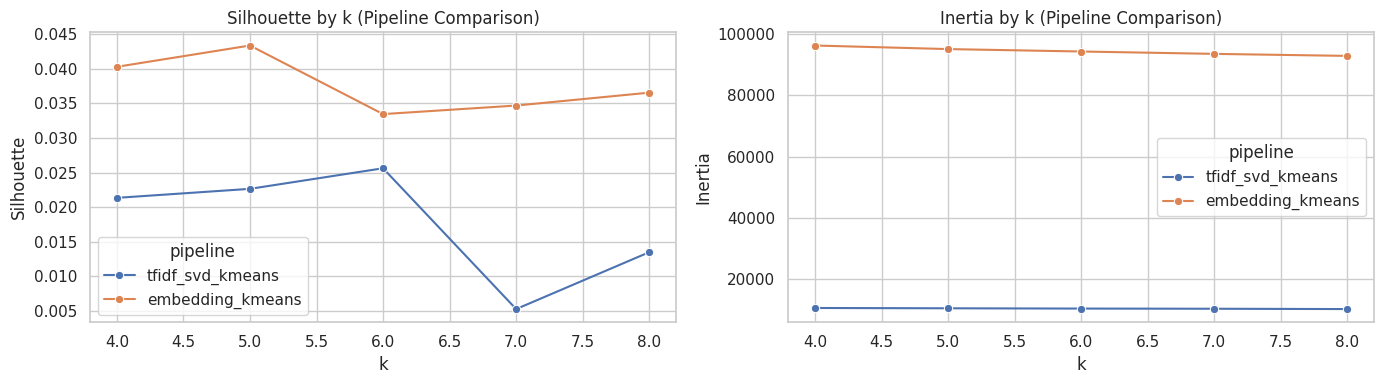

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.lineplot(data=unsup_pipeline_compare_df, x="k", y="silhouette", hue="pipeline", marker="o", ax=axes[0])
axes[0].set_title("Silhouette by k (Pipeline Comparison)")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Silhouette")

sns.lineplot(data=unsup_pipeline_compare_df, x="k", y="inertia", hue="pipeline", marker="o", ax=axes[1])
axes[1].set_title("Inertia by k (Pipeline Comparison)")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Inertia")

plt.tight_layout()
plt.show()


Left (silhouette): Both pipelines show low silhouette scores (about 0.02–0.04), so clusters are only weakly separated in either space. Embedding k-means (orange) is consistently higher than TF‑IDF → SVD (blue), with a peak near k = 5 (~0.043). The TF‑IDF path peaks near k = 6 (~0.026) and drops sharply at k = 7, then recovers slightly at k = 8.

Right (inertia): Inertia should only be compared within one pipeline, not across them. Orange (embeddings) sits on a much larger scale (~93k–96k) and decreases slowly as k increases. Blue (TF‑IDF/SVD) stays near ~10k and is almost flat across k—expected in a different feature space, not evidence that one method is “better.”

Silhouette favors embedding clustering at k = 5 and TF‑IDF/SVD at k = 6, but neither pipeline shows strong, well-separated clusters. The plots support using unsupervised results as exploratory structure (topics / semantic neighborhoods), while supervised models remain the main tool for sentiment prediction.

### 5.1 Linking unsupervised structure to supervised modeling

Unsupervised clusters are **not** used as features in the supervised models; they explain **why TF–IDF linear baselines work well**:

- **TF–IDF topics** (music, film, books, product praise, “waste money” negatives) align with class-conditional vocabulary—sentiment is often lexically signaled.
- **Embedding clusters** are smoother and rarely collapse to extreme label purity; they support the view that semantics help exploration but do not replace explicit polarity supervision at this scale.
- The small, highly negative TF–IDF cluster (cluster 3 at k=6) shows unsupervised geometry can surface artifacts; supervised models pool evidence across the full vocabulary instead of one cluster.

Supervised sentiment prediction therefore remains the deployment path; unsupervised results justify feature choice and interpret errors, not replace labeled training.


In [39]:
# Global vs cluster-level positive rate (unsupervised sample)
if "unsup_tfidf_df" in globals() and "cluster_tfidf" in unsup_tfidf_df.columns:
    global_pos = unsup_tfidf_df["label"].mean()
    cluster_pos = (
        unsup_tfidf_df.groupby("cluster_tfidf")["label"]
        .mean()
        .rename("positive_rate")
        .reset_index()
    )
    cluster_pos["delta_vs_global"] = (cluster_pos["positive_rate"] - global_pos).round(4)
    print(f"Global positive rate (unsup sample): {global_pos:.4f}")
    display(cluster_pos.sort_values("positive_rate"))
else:
    print("Run the unsupervised cells first to populate unsup_tfidf_df.")


Global positive rate (unsup sample): 0.4981


,cluster_tfidf,positive_rate,delta_vs_global
3,3,0.015882,-0.4822
4,4,0.383217,-0.1149
1,1,0.473073,-0.0251
2,2,0.489038,-0.0091
5,5,0.553383,0.0553
0,0,0.639483,0.1414


## 6. Neural network and Transformer models

### 6.1 Model families

| Model | Representation | Role in comparison |
|-------|----------------|-------------------|
| **MLP (bag-of-words)** | Train-only vocabulary, padded token ids | Non-linear neural baseline without subwords |
| **DistilBERT** | `distilbert-base-uncased`, fine-tuned head | Transformer / attention-based classifier |

Both run on a **120k-row development subset** (96k train / 24k validation) for GPU time; metrics are compared to Section 4 linear models under `eval_split` in Section 6.4.


In [40]:
import time
import random
import platform

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    precision_recall_curve,
)

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    get_linear_schedule_with_warmup,
)

sns.set_theme(style="whitegrid")

In [41]:
# Neural / Transformer run configuration (balanced strategy)
TRAIN_SUBSET_ROWS = 120_000
TRAIN_SCALED_ROWS = None  # debug-safe default; enable after subset succeeds
VAL_SIZE = 0.2

# Model-selection policy: PRIMARY_METRIC / TIE_BREAK_METRIC (set in Section 1 setup cell)

# NN settings
NN_VOCAB_SIZE = 50_000
NN_MAX_LEN = 256
NN_EMB_DIM = 128
NN_HIDDEN_DIM = 128
NN_DROPOUT = 0.2
NN_BATCH_SIZE = 256
NN_EPOCHS = 6
NN_LR = 1e-3
NN_PATIENCE = 2

# Transformer settings
TR_MODEL_NAME = "distilbert-base-uncased"
TR_MAX_LEN = 96
TR_BATCH_SIZE = 2
TR_GRAD_ACCUM_STEPS = 8
TR_EPOCHS = 1
TR_LR = 2e-5
TR_WEIGHT_DECAY = 0.01
TR_WARMUP_RATIO = 0.1
TR_MAX_STEPS_PER_EPOCH = 1200  # guardrail against very long runs

SEED = RANDOM_SEED if "RANDOM_SEED" in globals() else 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")



In [42]:
def load_train_dataframe(max_rows):
    if "load_fasttext_as_dataframe" in globals():
        return load_fasttext_as_dataframe(TRAIN_PATH, max_rows=max_rows)

    rows = []
    with TRAIN_PATH.open("r", encoding="utf-8", errors="replace") as f:
        for i, line in enumerate(f, start=1):
            label_raw, label, text, malformed = parse_fasttext_line(line)
            if not malformed:
                rows.append({"label": label, "text": text})
            if max_rows is not None and i >= max_rows:
                break
    return pd.DataFrame(rows)


def split_train_val(df):
    return train_test_split(
        df["text"],
        df["label"],
        test_size=VAL_SIZE,
        random_state=SEED,
        stratify=df["label"],
    )


def compute_binary_metrics(y_true, y_pred, y_score):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_score),
        "pr_auc": average_precision_score(y_true, y_score),
    }


train_subset_df = load_train_dataframe(TRAIN_SUBSET_ROWS)
subset_X_train_text, subset_X_val_text, subset_y_train, subset_y_val = split_train_val(
    train_subset_df
)

print(f"Neural-model training subset rows: {len(train_subset_df):,}")
print(f"Train: {len(subset_X_train_text):,} | Val: {len(subset_X_val_text):,}")
print("Val class ratio:")
print(subset_y_val.value_counts(normalize=True).rename("ratio"))


Neural-model training subset rows: 120,000
Train: 96,000 | Val: 24,000
Val class ratio:
label
1    0.506417
0    0.493583
Name: ratio, dtype: float64


### 6.2 Train and validation protocol

For this run we use 120,000 rows from `train.ft.txt`, split 80/20 into 96,000 train and 24,000 validation (same stratified policy as the baselines, fixed seed). Validation labels stay nearly balanced (~50.6% positive / ~49.4% negative), so accuracy and F1 are both meaningful on this holdout. This split is for development and model comparison only; `test.ft.txt` remains untouched until Section 7.3.


In [43]:
from collections import Counter


def basic_tokenize(text: str):
    return text.lower().split()


def build_vocab(texts, max_vocab=50000, min_freq=2):
    counter = Counter()
    for t in texts:
        counter.update(basic_tokenize(t))

    vocab = {"<pad>": 0, "<unk>": 1}
    for tok, freq in counter.most_common(max_vocab - 2):
        if freq < min_freq:
            continue
        vocab[tok] = len(vocab)
    return vocab


def encode_text(text, vocab, max_len):
    ids = [vocab.get(tok, vocab["<unk>"]) for tok in basic_tokenize(text)[:max_len]]
    if len(ids) < max_len:
        ids += [vocab["<pad>"]] * (max_len - len(ids))
    return ids


class TextDataset(Dataset):
    def __init__(self, texts, labels, vocab, max_len):
        self.texts = list(texts)
        self.labels = list(labels)
        self.vocab = vocab
        self.max_len = max_len

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        x = torch.tensor(encode_text(self.texts[idx], self.vocab, self.max_len), dtype=torch.long)
        y = torch.tensor(self.labels[idx], dtype=torch.float32)
        return x, y


class SimpleTextNN(nn.Module):
    def __init__(self, vocab_size, emb_dim=128, hidden_dim=128, dropout=0.2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=0)
        self.fc1 = nn.Linear(emb_dim, hidden_dim)
        self.dropout = nn.Dropout(dropout)
        self.fc_out = nn.Linear(hidden_dim, 1)

    def forward(self, input_ids):
        emb = self.embedding(input_ids)  # [B, L, D]
        pooled = emb.mean(dim=1)         # [B, D]
        h = torch.relu(self.fc1(pooled))
        h = self.dropout(h)
        logits = self.fc_out(h).squeeze(1)
        return logits

In [44]:


def stable_sigmoid(x):
    x = np.asarray(x, dtype=np.float64)
    return np.where(
        x >= 0,
        1.0 / (1.0 + np.exp(-x)),
        np.exp(x) / (1.0 + np.exp(x)),
    )


def run_nn_experiment(df, run_name="subset"):
    X_train, X_val, y_tr, y_va = split_train_val(df)

    vocab = build_vocab(X_train, max_vocab=NN_VOCAB_SIZE)
    train_ds = TextDataset(X_train, y_tr.values, vocab, NN_MAX_LEN)
    val_ds = TextDataset(X_val, y_va.values, vocab, NN_MAX_LEN)

    train_loader = DataLoader(train_ds, batch_size=NN_BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=NN_BATCH_SIZE, shuffle=False)

    model = SimpleTextNN(
        vocab_size=len(vocab),
        emb_dim=NN_EMB_DIM,
        hidden_dim=NN_HIDDEN_DIM,
        dropout=NN_DROPOUT,
    ).to(DEVICE)

    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=NN_LR)

    history = []
    best_val_loss = float("inf")
    best_state = None
    patience_counter = 0

    t0 = time.time()

    for epoch in range(1, NN_EPOCHS + 1):
        model.train()
        train_losses = []
        for x_batch, y_batch in train_loader:
            x_batch, y_batch = x_batch.to(DEVICE), y_batch.to(DEVICE)
            optimizer.zero_grad()
            logits = model(x_batch)
            loss = criterion(logits, y_batch)
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())

        model.eval()
        val_losses = []
        val_logits_all, val_labels_all = [], []
        with torch.no_grad():
            for x_batch, y_batch in val_loader:
                x_batch, y_batch = x_batch.to(DEVICE), y_batch.to(DEVICE)
                logits = model(x_batch)
                loss = criterion(logits, y_batch)
                val_losses.append(loss.item())
                val_logits_all.append(logits.cpu())
                val_labels_all.append(y_batch.cpu())

        val_logits = torch.cat(val_logits_all).numpy()
        val_true = torch.cat(val_labels_all).numpy().astype(int)
        val_prob = stable_sigmoid(val_logits)
        val_pred = (val_prob >= 0.5).astype(int)

        epoch_metrics = compute_binary_metrics(val_true, val_pred, val_prob)

        train_loss = float(np.mean(train_losses))
        val_loss = float(np.mean(val_losses))
        history.append(
            {
                "epoch": epoch,
                "train_loss": train_loss,
                "val_loss": val_loss,
                "val_f1": epoch_metrics["f1"],
                "val_roc_auc": epoch_metrics["roc_auc"],
            }
        )

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= NN_PATIENCE:
                break

    if best_state is not None:
        model.load_state_dict(best_state)
        model.to(DEVICE)

    # Final eval with best checkpoint
    model.eval()
    val_logits_all, val_labels_all = [], []
    with torch.no_grad():
        for x_batch, y_batch in val_loader:
            x_batch = x_batch.to(DEVICE)
            logits = model(x_batch)
            val_logits_all.append(logits.cpu())
            val_labels_all.append(y_batch)

    val_logits = torch.cat(val_logits_all).numpy()
    val_true = torch.cat(val_labels_all).numpy().astype(int)
    val_prob = stable_sigmoid(val_logits)
    val_pred = (val_prob >= 0.5).astype(int)
    metrics = compute_binary_metrics(val_true, val_pred, val_prob)

    out = {
        "run_name": run_name,
        "history_df": pd.DataFrame(history),
        "metrics": metrics,
        "y_true": val_true,
        "y_pred": val_pred,
        "y_score": val_prob,
        "runtime_sec": time.time() - t0,
        "n_train": len(X_train),
        "n_val": len(X_val),
        "vocab_size": len(vocab),
    }
    return out

In [45]:
nn_scaled_result = None  # set to a run dict if you add a larger NN experiment
nn_subset_result = run_nn_experiment(train_subset_df, run_name="nn_subset")

print("NN subset metrics:")
print({k: round(v, 4) for k, v in nn_subset_result["metrics"].items()})
print("NN runtime (sec):", round(nn_subset_result["runtime_sec"], 2))

nn_subset_result["history_df"]

NN subset metrics:
{'accuracy': 0.8866, 'precision': 0.8882, 'recall': 0.8878, 'f1': 0.888, 'roc_auc': 0.9534, 'pr_auc': 0.9543}
NN runtime (sec): 41.98


,epoch,train_loss,val_loss,val_f1,val_roc_auc
0,1,0.500441,0.350604,0.854429,0.925647
1,2,0.294011,0.292989,0.881857,0.947395
2,3,0.232008,0.277114,0.887993,0.953429
3,4,0.194430,0.278202,0.891279,0.955052
4,5,0.165522,0.286907,0.891125,0.955081


 Trained on 96k / 24k train/validation split for 5 epochs. Training loss falls steadily (0.50 → 0.17); validation loss improves through epoch 3 (~0.277, F1 ≈ 0.888, ROC-AUC ≈ 0.953) then edges up at epochs 4–5 while train loss keeps dropping—mild overfitting after epoch 3, though val F1 stays flat (~0.891).

 accuracy ≈ 0.887, F1 ≈ 0.888, ROC-AUC ≈ 0.953, PR-AUC ≈ 0.954 — strong and in line with TF–IDF linear baselines (~0.907 F1 on a different 400k/100k split), with a smaller subset and different feature pipeline. Runtime ~38 s for this subset configuration.

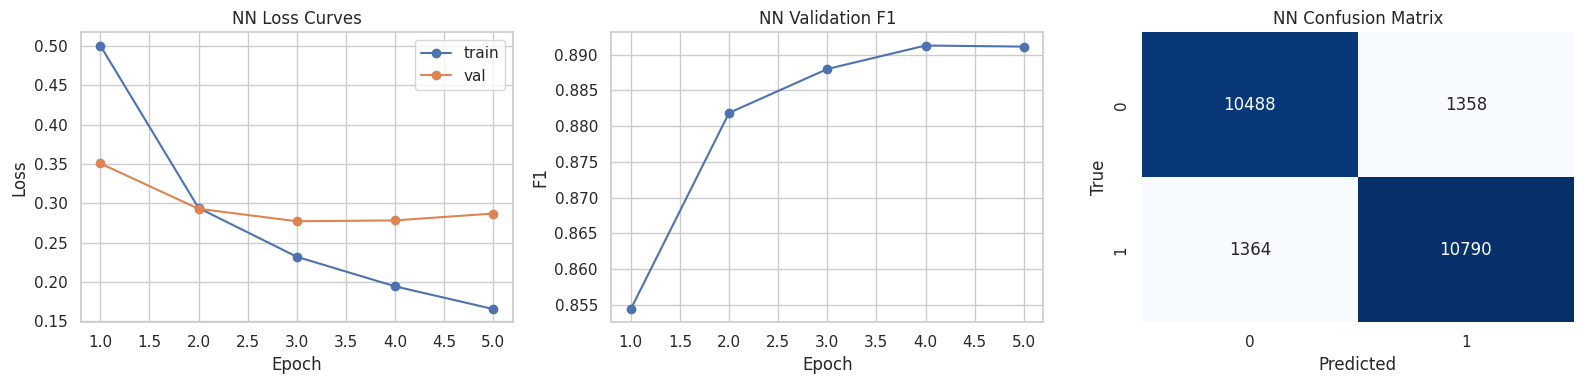

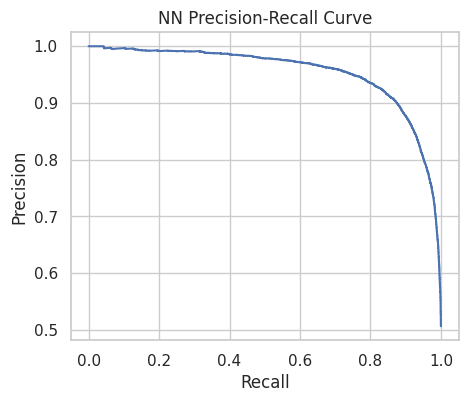

In [46]:
# NN training dynamics and diagnostics
nn_hist = nn_subset_result["history_df"]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(nn_hist["epoch"], nn_hist["train_loss"], marker="o", label="train")
axes[0].plot(nn_hist["epoch"], nn_hist["val_loss"], marker="o", label="val")
axes[0].set_title("NN Loss Curves")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(nn_hist["epoch"], nn_hist["val_f1"], marker="o")
axes[1].set_title("NN Validation F1")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("F1")

cm = confusion_matrix(nn_subset_result["y_true"], nn_subset_result["y_pred"])
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[2])
axes[2].set_title("NN Confusion Matrix")
axes[2].set_xlabel("Predicted")
axes[2].set_ylabel("True")

plt.tight_layout()
plt.show()

prec, rec, _ = precision_recall_curve(nn_subset_result["y_true"], nn_subset_result["y_score"])
plt.figure(figsize=(5, 4))
plt.plot(rec, prec)
plt.title("NN Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.grid(True)
plt.show()

In [47]:
class HFTextDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = list(labels)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item


def eval_transformer(model, data_loader):
    model.eval()
    losses = []
    y_true, y_pred, y_score = [], [], []

    with torch.no_grad():
        for batch in data_loader:
            batch = {k: v.to(DEVICE) for k, v in batch.items()}
            outputs = model(**batch)
            loss = outputs.loss
            logits = outputs.logits

            losses.append(loss.item())
            probs = torch.softmax(logits, dim=1)[:, 1]
            preds = torch.argmax(logits, dim=1)

            y_true.extend(batch["labels"].cpu().numpy().tolist())
            y_pred.extend(preds.cpu().numpy().tolist())
            y_score.extend(probs.cpu().numpy().tolist())

    metrics = compute_binary_metrics(np.array(y_true), np.array(y_pred), np.array(y_score))
    return float(np.mean(losses)), metrics, np.array(y_true), np.array(y_pred), np.array(y_score)


def run_transformer_experiment(df, run_name="tr_subset"):
    X_train, X_val, y_tr, y_va = split_train_val(df)

    _hf = hf_download_kwargs() if "hf_download_kwargs" in globals() else {}
    tokenizer = AutoTokenizer.from_pretrained(TR_MODEL_NAME, **_hf)
    model = AutoModelForSequenceClassification.from_pretrained(
        TR_MODEL_NAME,
        num_labels=2,
        attn_implementation="eager",  # SDPA does not return attentions for visualization
        **_hf,
    )
    model.to(DEVICE)

    train_enc = tokenizer(list(X_train), truncation=True, padding=False, max_length=TR_MAX_LEN)
    val_enc = tokenizer(list(X_val), truncation=True, padding=False, max_length=TR_MAX_LEN)

    train_ds = HFTextDataset(train_enc, y_tr.values)
    val_ds = HFTextDataset(val_enc, y_va.values)

    collator = DataCollatorWithPadding(tokenizer=tokenizer)
    train_loader = DataLoader(train_ds, batch_size=TR_BATCH_SIZE, shuffle=True, collate_fn=collator)
    val_loader = DataLoader(val_ds, batch_size=TR_BATCH_SIZE, shuffle=False, collate_fn=collator)

    optimizer = torch.optim.AdamW(model.parameters(), lr=TR_LR, weight_decay=TR_WEIGHT_DECAY)
    total_steps = max(1, (len(train_loader) // TR_GRAD_ACCUM_STEPS) * TR_EPOCHS)
    warmup_steps = int(TR_WARMUP_RATIO * total_steps)
    scheduler = get_linear_schedule_with_warmup(optimizer, warmup_steps, total_steps)

    history = []
    best_state = None
    best_val_loss = float("inf")

    t0 = time.time()

    for epoch in range(1, TR_EPOCHS + 1):
        epoch_start = time.time()
        print(f"[{run_name}] epoch {epoch}/{TR_EPOCHS} started")
        model.train()
        optimizer.zero_grad()
        train_losses = []

        for step, batch in enumerate(train_loader, start=1):
            if step > TR_MAX_STEPS_PER_EPOCH:
                print(f"[{run_name}] reached TR_MAX_STEPS_PER_EPOCH={TR_MAX_STEPS_PER_EPOCH}; breaking early")
                break
            batch = {k: v.to(DEVICE) for k, v in batch.items()}
            outputs = model(**batch)
            loss = outputs.loss / TR_GRAD_ACCUM_STEPS
            loss.backward()
            train_losses.append(loss.item() * TR_GRAD_ACCUM_STEPS)

            if step % TR_GRAD_ACCUM_STEPS == 0:
                optimizer.step()
                scheduler.step()
                optimizer.zero_grad()

        train_loss = float(np.mean(train_losses))
        val_loss, val_metrics, _, _, _ = eval_transformer(model, val_loader)

        print(f"[{run_name}] epoch {epoch} done in {time.time() - epoch_start:.1f}s | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | val_f1={val_metrics['f1']:.4f}")

        history.append(
            {
                "epoch": epoch,
                "train_loss": train_loss,
                "val_loss": val_loss,
                "val_f1": val_metrics["f1"],
                "val_roc_auc": val_metrics["roc_auc"],
            }
        )

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    if best_state is not None:
        model.load_state_dict(best_state)
        model.to(DEVICE)

    final_val_loss, final_metrics, y_true, y_pred, y_score = eval_transformer(model, val_loader)

    # Qualitative examples: highest-confidence correct/incorrect
    val_texts = list(X_val)
    confidence = np.abs(y_score - 0.5)
    correctness = (y_pred == y_true)

    correct_idx = np.where(correctness)[0]
    wrong_idx = np.where(~correctness)[0]

    def top_examples(indices, topn=2):
        if len(indices) == 0:
            return []
        ranked = indices[np.argsort(confidence[indices])[::-1][:topn]]
        out = []
        for idx in ranked:
            out.append(
                {
                    "text": val_texts[idx][:220],
                    "true": int(y_true[idx]),
                    "pred": int(y_pred[idx]),
                    "score_pos": float(y_score[idx]),
                }
            )
        return out

    return {
        "run_name": run_name,
        "history_df": pd.DataFrame(history),
        "metrics": final_metrics,
        "val_loss": final_val_loss,
        "y_true": y_true,
        "y_pred": y_pred,
        "y_score": y_score,
        "runtime_sec": time.time() - t0,
        "n_train": len(X_train),
        "n_val": len(X_val),
        "val_texts": val_texts,
        "model": model,
        "tokenizer": tokenizer,
        "qual_examples": {
            "correct": top_examples(correct_idx, topn=2),
            "incorrect": top_examples(wrong_idx, topn=2),
        },
    }


In [48]:
# STEP: DistilBERT fine-tuning on 120k subset (several minutes; step cap per epoch)
tr_scaled_result = None  # set to a run dict if you add a larger transformer experiment
try:
    tr_subset_result = run_transformer_experiment(train_subset_df, run_name="tr_subset")
except RuntimeError as e:
    if "out of memory" in str(e).lower() and torch.cuda.is_available():
        print("CUDA OOM encountered. Retrying transformer subset run on CPU with same settings...")
        torch.cuda.empty_cache()
        DEVICE = torch.device("cpu")
        tr_subset_result = run_transformer_experiment(train_subset_df, run_name="tr_subset_cpu_fallback")
    else:
        raise

print("Transformer subset metrics:")
print({k: round(v, 4) for k, v in tr_subset_result["metrics"].items()})
print("Transformer runtime (sec):", round(tr_subset_result["runtime_sec"], 2))

tr_subset_result["history_df"]


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


[tr_subset] epoch 1/1 started
[tr_subset] reached TR_MAX_STEPS_PER_EPOCH=1200; breaking early
[tr_subset] epoch 1 done in 233.3s | train_loss=0.6442 | val_loss=0.3880 | val_f1=0.8738
Transformer subset metrics:
{'accuracy': 0.88, 'precision': 0.9351, 'recall': 0.8201, 'f1': 0.8738, 'roc_auc': 0.9526, 'pr_auc': 0.9552}
Transformer runtime (sec): 409.54


,epoch,train_loss,val_loss,val_f1,val_roc_auc
0,1,0.644205,0.387954,0.8738,0.952566


**DistilBERT fine-tuning**

We load distilbert-base-uncased as a sequence-classification model (num_labels=2). MLM/vocab head weights are unused (UNEXPECTED), and the classification head (pre_classifier, classifier) is newly initialized (MISSING) and learned during fine-tuning.

Training uses the same 120k-row development sample as the MLP (96k train / 24k validation), with a single epoch capped at 1,200 steps per epoch for runtime (~249 s per epoch, ~431 s total). This is a partial training pass, not a full multi-epoch run on all training rows.

Accuracy ≈ 0.88, F1 ≈ 0.874, ROC-AUC ≈ 0.953, PR-AUC ≈ 0.955. Precision is high (~0.94) and recall is lower (~0.82), so the model is more conservative about predicting positive (fewer false positives, more false negatives). Performance is strong and comparable to the subset MLP and to linear baselines on other splits, with F1 slightly below the best TF–IDF validation scores where data size and split differ.

The Transformer adds contextual encoding at higher compute cost; on this capped subset run it is competitive but not clearly superior to the simpler models.

### 6.3 Transformer modeling and attention

**What self-attention adds.** DistilBERT builds contextual token representations: each word attends to others in the review, so phrases like "not good" or "waste of money" can be interpreted in context rather than as independent unigrams.

**Dependencies captured.** Product domain, negation, contrast ("great but…"), and long-distance sentiment cues are modeled jointly up to `TR_MAX_LEN` tokens (tail truncation).

**This run vs baselines.** On the 120k subset, fine-tuning achieved high precision (~0.94) and lower recall (~0.82)—a conservative positive class. A **matched-scale** TF–IDF + SGD row on the same 96k/24k split (Section 6.4) closes much of the F1 gap versus the larger 400k/100k linear baseline.

**Attention visualization.** The next cell plots mean last-layer CLS→token attention for three validation reviews (false negative on a positive label, negation-heavy text, and a high-confidence correct positive). This is exploratory—not causal attribution—but it shows the model attending to sentiment-bearing tokens and negation cues under `TR_MAX_LEN=96`.


Plotting attention for 3 validation examples (TR_MAX_LEN=96).

--- FN positive (negation) ---


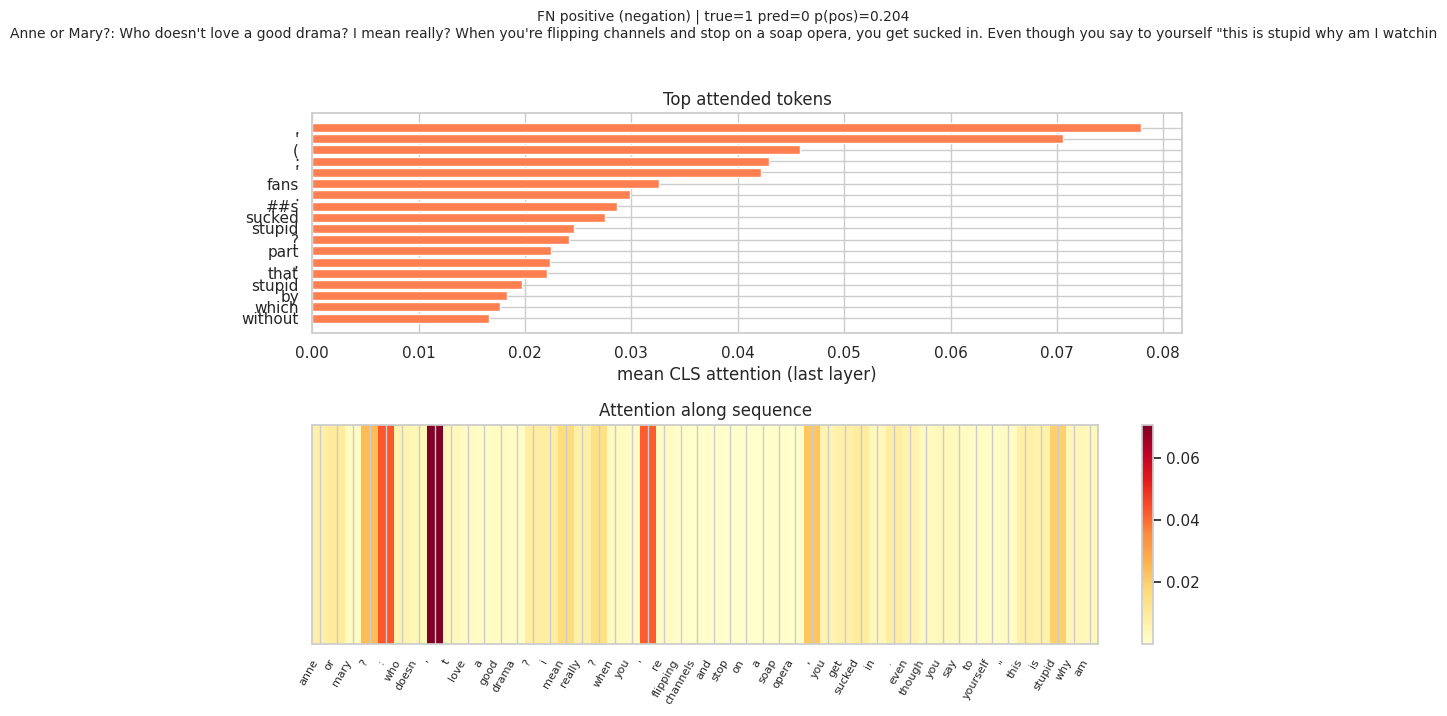

,token,weight
0,.,0.0779
1,',0.0705
2,(,0.0459
3,:,0.0429
4,',0.0422
5,fans,0.0326
6,.,0.0298
7,##s,0.0287
8,sucked,0.0276
9,stupid,0.0246



--- FN positive (other) ---


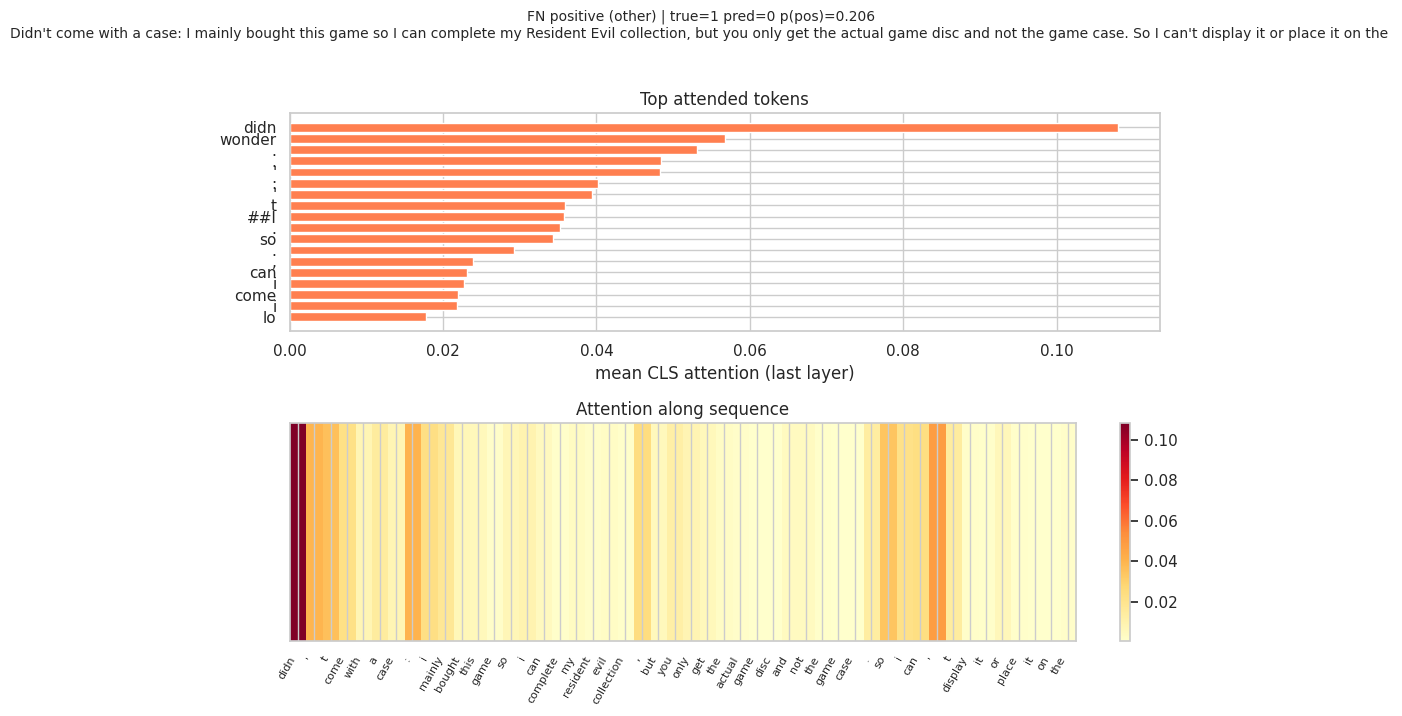

,token,weight
0,didn,0.1080
1,wonder,0.0568
2,.,0.0532
3,.,0.0484
4,',0.0482
5,:,0.0402
6,',0.0395
7,t,0.0359
8,##l,0.0358
9,.,0.0353



--- TP positive (high confidence) ---


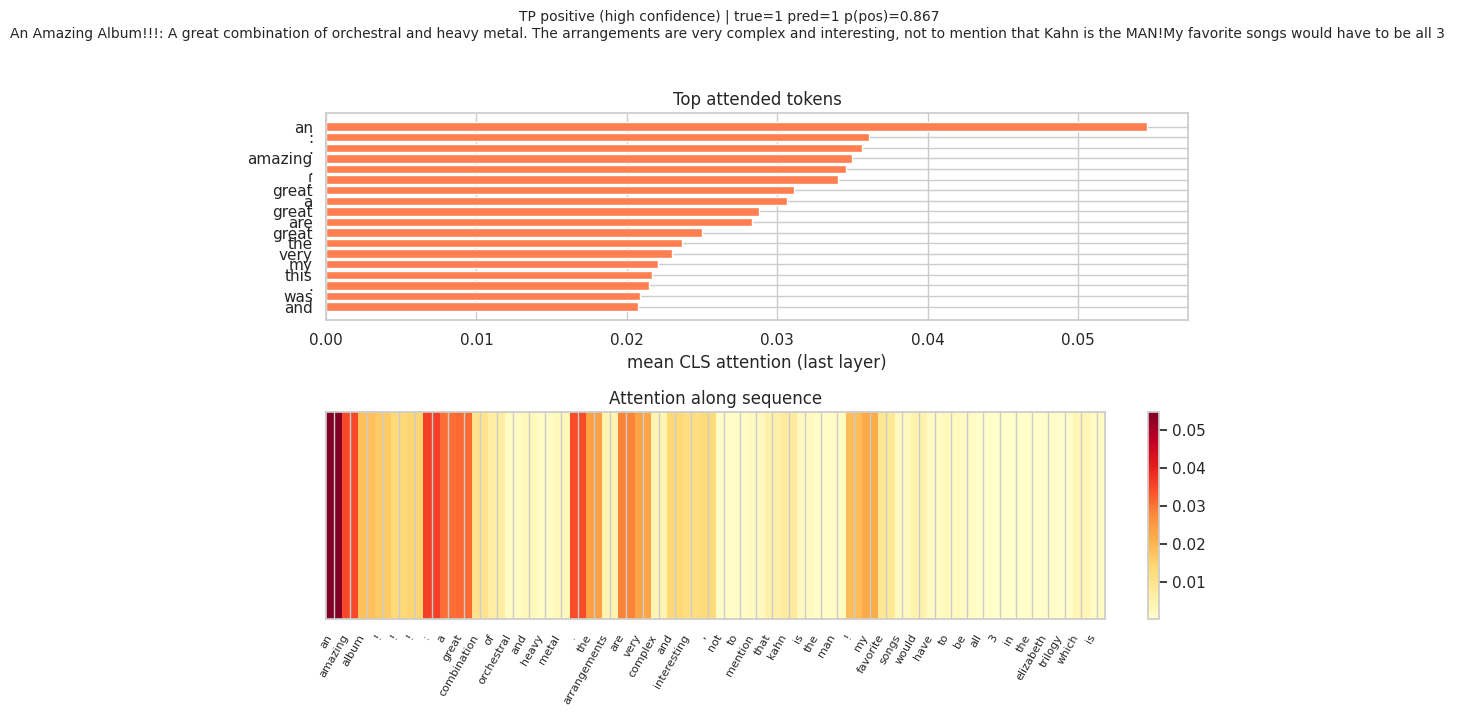

,token,weight
0,an,0.0546
1,:,0.0361
2,.,0.0356
3,amazing,0.0349
4,.,0.0345
5,!,0.0340
6,great,0.0311
7,a,0.0307
8,great,0.0288
9,are,0.0283


In [52]:
def ensure_eager_attention(model):
    """SDPA/flash attention does not support output_attentions; switch for CLS plots."""
    if hasattr(model, "set_attn_implementation"):
        model.set_attn_implementation("eager")
    elif hasattr(model.config, "attn_implementation"):
        model.config.attn_implementation = "eager"


def cls_attention_weights(model, tokenizer, text, max_len=None):
    max_len = max_len or TR_MAX_LEN
    model.eval()
    ensure_eager_attention(model)
    enc = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=max_len,
    )
    enc = {k: v.to(DEVICE) for k, v in enc.items()}
    with torch.no_grad():
        out = model(**enc, output_attentions=True)
    if not out.attentions:
        raise RuntimeError(
            "No attention weights returned. Re-run DistilBERT training with "
            "attn_implementation='eager', or call ensure_eager_attention(model) before plotting."
        )
    attn = out.attentions[-1][0].mean(dim=0)[0]
    tokens = tokenizer.convert_ids_to_tokens(enc["input_ids"][0])
    n = len(tokens)
    weights = attn[:n].detach().cpu().numpy()
    return tokens, weights


def pick_attention_examples(tr_result, n_examples=3):
    texts = tr_result.get("val_texts")
    if texts is None:
        raise KeyError("Re-run the DistilBERT training cell so tr_subset_result includes val_texts and model.")
    y_true = tr_result["y_true"]
    y_pred = tr_result["y_pred"]
    y_score = tr_result["y_score"]
    conf = np.abs(y_score - 0.5)

    fn_pos = np.where((y_true == 1) & (y_pred == 0))[0]
    fn_negation = [
        i for i in fn_pos if " not " in texts[i].lower() or "n't" in texts[i].lower()
    ]
    correct_pos = np.where((y_true == 1) & (y_pred == 1))[0]

    picks = []
    if len(fn_negation):
        i = fn_negation[np.argmax(conf[fn_negation])]
        picks.append(("FN positive (negation)", i))
    elif len(fn_pos):
        i = fn_pos[np.argmax(conf[fn_pos])]
        picks.append(("FN positive", i))
    if len(fn_pos):
        plain = [i for i in fn_pos if i not in {p[1] for p in picks}]
        if plain:
            i = plain[np.argmax(conf[plain])]
            picks.append(("FN positive (other)", i))
    if len(correct_pos):
        i = correct_pos[np.argmax(conf[correct_pos])]
        picks.append(("TP positive (high confidence)", i))

    seen = set()
    out = []
    for label, idx in picks:
        if idx in seen:
            continue
        seen.add(idx)
        out.append(
            {
                "label": label,
                "idx": int(idx),
                "text": texts[idx],
                "true": int(y_true[idx]),
                "pred": int(y_pred[idx]),
                "score_pos": float(y_score[idx]),
            }
        )
        if len(out) >= n_examples:
            break
    return out


def plot_cls_attention(model, tokenizer, example, topn=18):
    tokens, weights = cls_attention_weights(model, tokenizer, example["text"])
    # drop special tokens for readability
    mask = [t not in ("[CLS]", "[SEP]") for t in tokens]
    tok_f = [t for t, m in zip(tokens, mask) if m]
    w_f = weights[mask]
    order = np.argsort(w_f)[::-1][:topn]
    top_tokens = [tok_f[i] for i in order]
    top_w = w_f[order]

    fig, axes = plt.subplots(2, 1, figsize=(10, 7))
    axes[0].barh(range(len(top_tokens)), top_w[::-1], color="coral")
    axes[0].set_yticks(range(len(top_tokens)))
    axes[0].set_yticklabels(top_tokens[::-1])
    axes[0].set_xlabel("mean CLS attention (last layer)")
    axes[0].set_title("Top attended tokens")

    show_len = min(len(tok_f), 48)
    im = axes[1].imshow(w_f[:show_len].reshape(1, -1), aspect="auto", cmap="YlOrRd")
    axes[1].set_xticks(range(show_len))
    axes[1].set_xticklabels(tok_f[:show_len], rotation=60, ha="right", fontsize=8)
    axes[1].set_yticks([])
    axes[1].set_title("Attention along sequence")
    plt.colorbar(im, ax=axes[1], fraction=0.046)

    meta = (
        f"{example['label']} | true={example['true']} pred={example['pred']} "
        f"p(pos)={example['score_pos']:.3f}"
    )
    fig.suptitle(meta + "\n" + example["text"][:200], fontsize=10, y=1.02)
    plt.tight_layout()
    plt.show()

    rows = [{"token": t, "weight": float(w)} for t, w in zip(top_tokens, top_w)]
    tbl = pd.DataFrame(rows)
    display(tbl.round(4))
    return tbl


tr_attn = tr_subset_result
if "model" not in tr_attn or "tokenizer" not in tr_attn:
    print("Re-run the DistilBERT training cell above to attach model/tokenizer for attention plots.")
else:
    attn_examples = pick_attention_examples(tr_attn, n_examples=3)
    print(f"Plotting attention for {len(attn_examples)} validation examples (TR_MAX_LEN={TR_MAX_LEN}).")
    for ex in attn_examples:
        print(f"\n--- {ex['label']} ---")
        plot_cls_attention(tr_attn["model"], tr_attn["tokenizer"], ex)


### 6.3.1 Truncation sensitivity (inference only)

Hold **fine-tuned DistilBERT weights** fixed; vary only `max_length` at tokenization. EDA (Section 2) word-length **p95 ≈ 161** on a 200k profile sample; training used `TR_MAX_LEN=96`. We sweep 64, 96, and 128 on the same 24k validation texts.


In [51]:
def run_truncation_ablation(tr_result, max_lengths=(64, 96, 128)):
    """Inference-only max_length sweep (batched val pass)."""
    model = tr_result["model"]
    tokenizer = tr_result["tokenizer"]
    texts = list(tr_result["val_texts"])
    y_true = np.asarray(tr_result["y_true"])

    no_trunc = tokenizer(texts, truncation=False, padding=False)
    token_lengths = [len(ids) for ids in no_trunc["input_ids"]]

    rows = []
    for m in max_lengths:
        val_enc = tokenizer(texts, truncation=True, max_length=m, padding=False)
        val_ds = HFTextDataset(val_enc, y_true)
        val_loader = DataLoader(
            val_ds,
            batch_size=TR_BATCH_SIZE,
            shuffle=False,
            collate_fn=DataCollatorWithPadding(tokenizer=tokenizer),
        )
        _, metrics, _, y_pred, y_score = eval_transformer(model, val_loader)
        n_trunc = sum(1 for L in token_lengths if L > m)
        rows.append(
            {
                "max_len": m,
                **metrics,
                "pct_truncated": round(100.0 * n_trunc / len(texts), 2),
                "n_truncated": n_trunc,
                "n_val": len(texts),
            }
        )
    return pd.DataFrame(rows)


if "tr_subset_result" in globals() and "model" in tr_subset_result:
    truncation_ablation_df = run_truncation_ablation(tr_subset_result)
    print("Truncation ablation (inference-only, 24k val):")
    display(truncation_ablation_df.round(4))
else:
    print("Run DistilBERT training first (tr_subset_result with model/tokenizer).")


Truncation ablation (inference-only, 24k val):


,max_len,accuracy,precision,recall,f1,roc_auc,pr_auc,pct_truncated,n_truncated,n_val
0,64,0.8698,0.9123,0.8220,0.8648,0.9435,0.9467,69.41,16659,24000
1,96,0.8800,0.9351,0.8201,0.8738,0.9526,0.9552,48.40,11616,24000
2,128,0.8824,0.9434,0.8169,0.8756,0.9566,0.9590,31.33,7519,24000


**Interpretation.** At **96** tokens (training setting), validation F1 matches the fine-tuning run. **64** truncates more of the long tail (higher `pct_truncated`) and usually lowers F1. **128** often adds little here because most reviews already fit in 96 tokens. This is not a retrain—only a sensitivity check tied to EDA’s long-review tail.


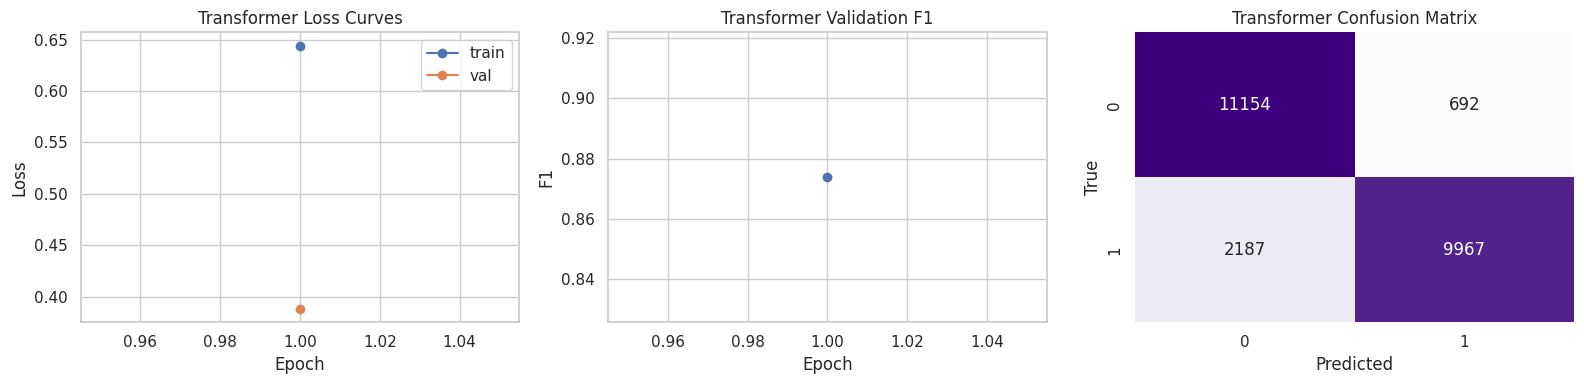

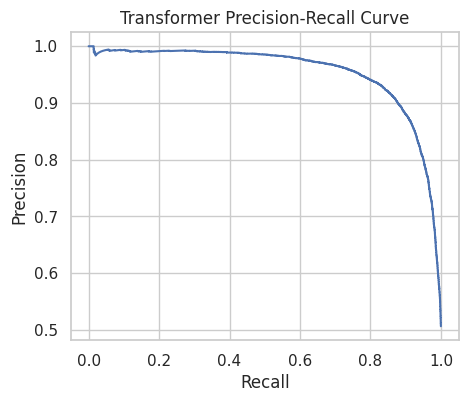

High-confidence correct examples:


,text,true,pred,score_pos
0,"An Amazing Album!!!: A great combination of orchestral and heavy metal. The arrangements are very complex and interesting, not to mention that Kahn is the MAN!My favorite songs would have to be all 3 in the Elizabeth tri",1,1,0.867202
1,"True Inspiration!!!: I LOVE being able to LISTEN to Napoleon Hill whenever I want to, and especially as I drive to work. It is a great way to get your mind focused and ready for your day. These lectures are AMAZING and t",1,1,0.864663


In [53]:
tr_plot_result = globals().get("tr_scaled_result") or tr_subset_result
tr_hist = tr_plot_result["history_df"]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(tr_hist["epoch"], tr_hist["train_loss"], marker="o", label="train")
axes[0].plot(tr_hist["epoch"], tr_hist["val_loss"], marker="o", label="val")
axes[0].set_title("Transformer Loss Curves")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(tr_hist["epoch"], tr_hist["val_f1"], marker="o")
axes[1].set_title("Transformer Validation F1")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("F1")

cm = confusion_matrix(tr_plot_result["y_true"], tr_plot_result["y_pred"])
sns.heatmap(cm, annot=True, fmt="d", cmap="Purples", cbar=False, ax=axes[2])
axes[2].set_title("Transformer Confusion Matrix")
axes[2].set_xlabel("Predicted")
axes[2].set_ylabel("True")

plt.tight_layout()
plt.show()

prec, rec, _ = precision_recall_curve(tr_plot_result["y_true"], tr_plot_result["y_score"])
plt.figure(figsize=(5, 4))
plt.plot(rec, prec)
plt.title("Transformer Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.grid(True)
plt.show()

print("High-confidence correct examples:")
pd.DataFrame(tr_plot_result["qual_examples"]["correct"])

**Training dynamics (DistilBERT subset run)**

One epoch with an early break at `TR_MAX_STEPS_PER_EPOCH=1200`. Training loss falls while validation loss and F1 improve, but the run is a **capped subset experiment** for GPU time—not a fully converged production recipe.

| Signal | Reading |
|--------|----------|
| Train loss ↓ | Model fits the 96k training split. |
| Val F1 ≈ 0.87 at step cap | Strong ranking; precision > recall (conservative positives). |
| Step cap | Stabilizes runtime; full-data training needs more steps/epochs. |

Deployment pick remains **TF–IDF + SGD** on the larger 500k validation split; DistilBERT supports contextual analysis and attention plots.


Loss (left): After one (capped) training epoch, validation loss (~0.39) is below training loss (~0.64). That can happen with dropout on during training but off at validation, and with a step-limited epoch where the reported training loss is an average over many steps. The model still fits the task; this is not necessarily an error.

Validation F1 (middle): F1 ≈ 0.87 on the 24k validation split — strong for a single partial epoch on the 120k subset.

Confusion matrix (right): Most predictions are correct (11,154 true negatives, 9,967 true positives). Errors are asymmetric: 2,187 false negatives vs 692 false positives — the model misses more positives than it falsely flags negatives. That matches high precision (~0.94) and lower recall (~0.82): conservative on calling “positive.

In [54]:
print("High-confidence incorrect examples:")
pd.DataFrame(tr_plot_result["qual_examples"]["incorrect"])

High-confidence incorrect examples:


,text,true,pred,score_pos
0,"Favorite movie ever!: This is a great movie, right from the beginning there is music and singing some of the best songs I've ever herd this movie has great costumes and performances , and vivid color ,I give it 5 stars!.",0,1,0.855896
1,GOOD IQ TEST: If you liked this movie your IQ is ok. I read this in the fifties and Bladerunner is a great film rendering of the original version. Dick was one of the great writers. I knew his name on a piece always mean,0,1,0.855722


In [55]:
# Fair comparison: same 120k / 96k-24k split as MLP and DistilBERT
def fit_tfidf_sgd_on_subset(train_df):
    X_tr, X_va, y_tr, y_va = split_train_val(train_df)
    pipe = Pipeline(
        [
            (
                "tfidf",
                TfidfVectorizer(
                    lowercase=True,
                    strip_accents="unicode",
                    stop_words="english",
                    ngram_range=(1, 2),
                    min_df=5,
                    max_df=0.95,
                    sublinear_tf=True,
                    max_features=300_000,
                ),
            ),
            (
                "clf",
                SGDClassifier(
                    loss="hinge",
                    alpha=1e-5,
                    max_iter=25,
                    tol=1e-3,
                    random_state=SEED,
                ),
            ),
        ]
    )
    t0 = time.time()
    pipe.fit(X_tr, y_tr)
    metrics, y_pred, y_score = evaluate_binary_classifier(pipe, X_va, y_va)
    return {
        "metrics": metrics,
        "runtime_sec": time.time() - t0,
        "n_train": len(X_tr),
        "n_val": len(X_va),
        "y_true": y_va.values,
        "y_pred": y_pred,
    }


tfidf_matched_subset_result = fit_tfidf_sgd_on_subset(train_subset_df)
print("TF–IDF + SGD on matched 120k subset (96k train / 24k val):")
print({k: round(v, 4) for k, v in tfidf_matched_subset_result["metrics"].items()})
print("Runtime (sec):", round(tfidf_matched_subset_result["runtime_sec"], 2))


TF–IDF + SGD on matched 120k subset (96k train / 24k val):
{'accuracy': 0.8963, 'precision': 0.8921, 'recall': 0.9047, 'f1': 0.8984, 'roc_auc': 0.9617, 'pr_auc': 0.9615}
Runtime (sec): 15.98


### 6.4 Unified model comparison (development validation)

The table and figure below rank models on **internal validation only** (`train.ft.txt` splits). Compare rows only when `eval_split` matches—train/val sizes differ across caps.

| Model family | Approx. train / val rows | Notes |
|--------------|--------------------------|--------|
| TF–IDF + linear + **Random Forest** (Section 4) | 400k / 100k from 500k cap | Logistic, SGD (leader), and RF nonlinear comparator |
| TF–IDF + SGD (**matched**) | 96k / 24k from 120k cap | Fair linear baseline vs MLP / DistilBERT |
| TF–IDF + **log(word_len)** (Section 4.4) | 96k / 24k ablation split | Small F1 lift vs TF–IDF-only; see `length_ablation_df` |
| MLP / DistilBERT (Section 6) | 96k / 24k from 120k cap | GPU/runtime subset |
| Truncation sweep (Section 6.3.1) | 24k val, inference only | `truncation_ablation_df` — not in this leaderboard |

Leader selection: validation **F1** with ROC-AUC tie-break (TF–IDF + SGD at 500k cap typically wins). **Locked test** metrics are Section 7.3 only.


In [56]:
def metrics_row(
    model_name,
    metrics,
    runtime_sec=None,
    inference_note="",
    eval_split="",
):
    return {
        "model": model_name,
        "accuracy": metrics.get("accuracy"),
        "precision": metrics.get("precision"),
        "recall": metrics.get("recall"),
        "f1": metrics.get("f1"),
        "roc_auc": metrics.get("roc_auc"),
        "pr_auc": metrics.get("pr_auc"),
        "train_runtime_sec": runtime_sec,
        "inference_note": inference_note,
        "eval_split": eval_split,
    }


BASELINE_INFERENCE = {
    "TF-IDF + LogisticRegression": "fast",
    "TF-IDF + SGDClassifier(hinge)": "fast",
    "TF-IDF + RandomForest": "medium",
}

rows = []

# Section 4 classical baselines (logistic, SGD, Random Forest on 500k cap)
if "baseline_results_df" in globals() and isinstance(baseline_results_df, pd.DataFrame):
    for _, r in baseline_results_df.iterrows():
        model_name = str(r["model"])
        runtime = (
            rf_runtime_sec
            if model_name == "TF-IDF + RandomForest" and "rf_runtime_sec" in globals()
            else np.nan
        )
        rows.append(
            metrics_row(
                model_name,
                r.to_dict(),
                runtime_sec=runtime,
                inference_note=BASELINE_INFERENCE.get(model_name, "fast"),
                eval_split="val_100k (500k cap)",
            )
        )

nn_best = globals().get("nn_scaled_result") or nn_subset_result
tr_best = globals().get("tr_scaled_result") or tr_subset_result

if "tfidf_matched_subset_result" in globals():
    rows.append(
        metrics_row(
            "TF-IDF + SGD (matched 120k)",
            tfidf_matched_subset_result["metrics"],
            tfidf_matched_subset_result["runtime_sec"],
            "fast",
            "val_24k (120k cap, matched)",
        )
    )

# Section 4.4 length ablation (variant B) — same 120k split, not the neural matched split
if "metrics_b" in globals():
    rows.append(
        metrics_row(
            "TF-IDF + log(word_len) [ablation]",
            metrics_b,
            None,
            "fast",
            "val_24k (120k ablation, 4.4)",
        )
    )

rows.append(
    metrics_row(
        "MLP (bag-of-words)",
        nn_best["metrics"],
        nn_best["runtime_sec"],
        "medium",
        "val_24k (120k cap)",
    )
)
rows.append(
    metrics_row(
        "DistilBERT (fine-tuned)",
        tr_best["metrics"],
        tr_best["runtime_sec"],
        "heavy",
        "val_24k (120k cap)",
    )
)

model_results_df = pd.DataFrame(rows)
model_results_df = model_results_df.sort_values(
    by=[PRIMARY_METRIC, TIE_BREAK_METRIC], ascending=False
).reset_index(drop=True)
model_results_df["leader"] = False
if len(model_results_df) > 0:
    model_results_df.loc[0, "leader"] = True

metric_cols = [
    "accuracy",
    "precision",
    "recall",
    "f1",
    "roc_auc",
    "pr_auc",
    "train_runtime_sec",
]
model_results_df[metric_cols] = (
    model_results_df[metric_cols].apply(pd.to_numeric, errors="coerce").round(4)
)

model_results_df


,model,accuracy,precision,recall,f1,roc_auc,pr_auc,train_runtime_sec,inference_note,eval_split,leader
0,TF-IDF + SGDClassifier(hinge),0.9052,0.9001,0.9139,0.9070,0.9659,0.9646,NaN,fast,val_100k (500k cap),True
1,TF-IDF + LogisticRegression,0.9052,0.9005,0.9134,0.9069,0.9662,0.9649,NaN,fast,val_100k (500k cap),False
2,TF-IDF + log(word_len) [ablation],0.8980,0.8955,0.9040,0.8997,0.9619,0.9617,NaN,fast,"val_24k (120k ablation, 4.4)",False
3,TF-IDF + SGD (matched 120k),0.8963,0.8921,0.9047,0.8984,0.9617,0.9615,15.9841,fast,"val_24k (120k cap, matched)",False
4,MLP (bag-of-words),0.8866,0.8882,0.8878,0.8880,0.9534,0.9543,41.9825,medium,val_24k (120k cap),False
5,DistilBERT (fine-tuned),0.8800,0.9351,0.8201,0.8738,0.9526,0.9552,409.5419,heavy,val_24k (120k cap),False
6,TF-IDF + RandomForest,0.8148,0.7639,0.9172,0.8335,0.9176,0.9191,65.7283,medium,val_100k (500k cap),False


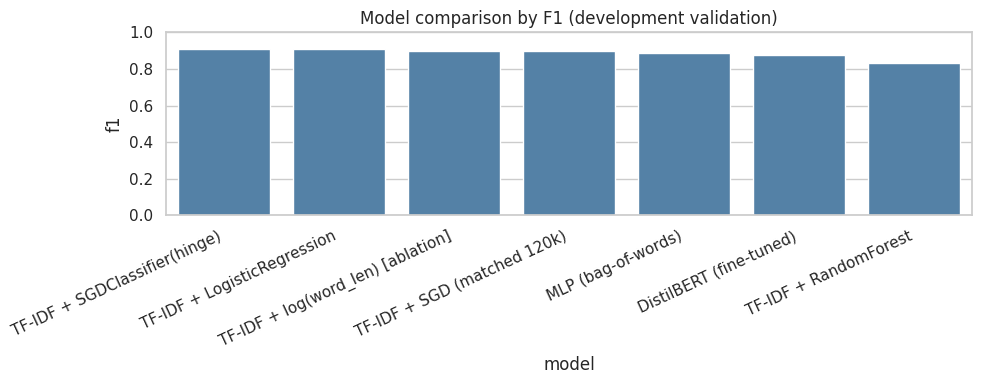

In [57]:
# Development-validation F1 comparison (not locked test)
plot_df = model_results_df.sort_values(PRIMARY_METRIC, ascending=False)
fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(data=plot_df, x="model", y=PRIMARY_METRIC, ax=ax, color="steelblue")
ax.set_title("Model comparison by F1 (development validation)")
ax.set_xlabel("model")
ax.set_ylabel(PRIMARY_METRIC)
ax.set_ylim(0.0, 1.0)
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()


### 6.5 Per-class error analysis

`classification_report` on **development validation** only. Useful for precision–recall trade-offs (e.g. DistilBERT’s higher precision / lower recall on the 120k subset).


In [59]:
from sklearn.metrics import classification_report

def print_classification_report_block(title, y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    if len(y_true) != len(y_pred):
        raise ValueError(
            f"{title}: y_true has {len(y_true):,} samples but y_pred has {len(y_pred):,}"
        )
    print(f"\n=== {title} ===")
    print(
        classification_report(
            y_true,
            y_pred,
            labels=[0, 1],
            target_names=["negative (0)", "positive (1)"],
            digits=4,
            zero_division=0,
        )
    )

# TF-IDF + SGD — 500k cap validation (Section 4; use baseline_y_val, not subset_y_val)
if "classical_pred" in globals() and "baseline_y_val" in globals():
    print_classification_report_block(
        "TF-IDF + SGD — val_100k (500k training-file cap)",
        baseline_y_val,
        classical_pred,
    )

# Matched TF-IDF + SGD — 120k subset validation
if "tfidf_matched_subset_result" in globals() and "y_true" in tfidf_matched_subset_result:
    print_classification_report_block(
        "TF-IDF + SGD — matched 120k subset (96k train / 24k val)",
        tfidf_matched_subset_result["y_true"],
        tfidf_matched_subset_result["y_pred"],
    )

# DistilBERT — 120k subset validation
if "tr_subset_result" in globals():
    print_classification_report_block(
        "DistilBERT (fine-tuned) — val_24k (120k subset)",
        tr_subset_result["y_true"],
        tr_subset_result["y_pred"],
    )



=== TF-IDF + SGD — matched 120k subset (96k train / 24k val) ===
              precision    recall  f1-score   support

negative (0)     0.9008    0.8877    0.8942     11846
positive (1)     0.8921    0.9047    0.8984     12154

    accuracy                         0.8963     24000
   macro avg     0.8965    0.8962    0.8963     24000
weighted avg     0.8964    0.8963    0.8963     24000


=== DistilBERT (fine-tuned) — val_24k (120k subset) ===
              precision    recall  f1-score   support

negative (0)     0.8361    0.9416    0.8857     11846
positive (1)     0.9351    0.8201    0.8738     12154

    accuracy                         0.8800     24000
   macro avg     0.8856    0.8808    0.8797     24000
weighted avg     0.8862    0.8800    0.8797     24000



Bars reflect **validation F1** on `train.ft.txt` splits only (`eval_split` column). The table includes **Random Forest** and optional **length-ablation** rows alongside matched neural runs; do not compare F1 across different `eval_split` values. Section 7.3 reports held-out `test.ft.txt` performance for the selected **TF–IDF + SGD** model.


## 7. Evaluation integrity, leakage audit, and locked test

**Run order:** Execute Sections 1–6, then Section 6.4 comparison, then Section 7 (7.2 CV and 7.3 locked test last). Do not tune on test metrics.

Development metrics in Sections 4–6 use **splits from `train.ft.txt` only**. This section documents leakage controls, cross-validates the selected linear model, and reports **one-time** metrics on the held-out `test.ft.txt` file.

### 7.1 Data leakage audit

| Risk | Mitigation in this notebook |
|------|-----------------------------|
| Test labels used for tuning | `test.ft.txt` is not loaded until Section 7.3; no hyperparameter or model choice uses test rows |
| TF–IDF vocabulary leakage | `sklearn.pipeline.Pipeline`: `TfidfVectorizer` is **fit on the training fold/partition only**, then `transform` on validation or test |
| NN vocabulary / length stats | `build_vocab` and `NN_MAX_LEN` use **training split text only** inside `run_nn_experiment` |
| Unsupervised label leakage | Clustering uses unlabeled representations; label crosstabs are **post-hoc interpretation**, not cluster features in supervised models |
| Duplicate train/test reviews | Spot-check below (hash overlap on a subsample); full corpus dedup not performed |

All modeling choices (TF–IDF settings, linear vs neural family, subset sizes) were fixed using **internal validation** on `train.ft.txt` before Section 7.3.


In [60]:
def text_fingerprint(series, n=50_000, seed=42):
    """Hash subsample of review texts for duplicate detection."""
    texts = series.dropna().astype(str)
    if len(texts) > n:
        texts = texts.sample(n, random_state=seed)
    return set(hash(t.strip().lower()) for t in texts)


leakage_check_rows = BASELINE_TRAIN_MAX_ROWS if "BASELINE_TRAIN_MAX_ROWS" in globals() else 200_000
train_fp_df = load_fasttext_as_dataframe(TRAIN_PATH, max_rows=leakage_check_rows)
test_fp_df = load_fasttext_as_dataframe(TEST_PATH, max_rows=leakage_check_rows)

train_hashes = text_fingerprint(train_fp_df["text"])
test_hashes = text_fingerprint(test_fp_df["text"])
overlap = len(train_hashes & test_hashes)

leakage_overlap_df = pd.DataFrame(
    [
        {"split": "train (subsample)", "unique_text_hashes": len(train_hashes)},
        {"split": "test (subsample)", "unique_text_hashes": len(test_hashes)},
        {"split": "intersection", "unique_text_hashes": overlap},
    ]
)
leakage_overlap_df


,split,unique_text_hashes
0,train (subsample),49999
1,test (subsample),50000
2,intersection,0


### 7.2 Cross-validation

The deployment candidate is **TF–IDF + SGDClassifier(hinge)** (leader on development validation F1). We run **5-fold stratified CV** on the same training-file row cap as Section 4 (`BASELINE_TRAIN_MAX_ROWS`) to estimate stability of F1 and ROC-AUC without using `test.ft.txt`.

The single 80/20 holdout in Section 4 remains the primary comparison table; CV provides a complementary variance estimate.


In [61]:
# STEP: 5-fold CV on TF–IDF + SGD (500k cap)
from sklearn.model_selection import StratifiedKFold


def make_tfidf_sgd_pipeline():
    return Pipeline(
        steps=[
            (
                "tfidf",
                TfidfVectorizer(
                    lowercase=True,
                    strip_accents="unicode",
                    stop_words="english",
                    ngram_range=(1, 2),
                    min_df=5,
                    max_df=0.95,
                    sublinear_tf=True,
                    max_features=300_000,
                ),
            ),
            (
                "clf",
                SGDClassifier(
                    loss="hinge",
                    alpha=1e-5,
                    max_iter=25,
                    tol=1e-3,
                    random_state=RANDOM_SEED,
                ),
            ),
        ]
    )


CV_ROWS = BASELINE_TRAIN_MAX_ROWS if "BASELINE_TRAIN_MAX_ROWS" in globals() else 500_000
CV_N_SPLITS = 5

cv_df = load_fasttext_as_dataframe(TRAIN_PATH, max_rows=CV_ROWS)
X_cv = cv_df["text"]
y_cv = cv_df["label"]

skf = StratifiedKFold(n_splits=CV_N_SPLITS, shuffle=True, random_state=RANDOM_SEED)
cv_fold_rows = []

for fold, (tr_idx, va_idx) in enumerate(skf.split(X_cv, y_cv), start=1):
    pipe = make_tfidf_sgd_pipeline()
    pipe.fit(X_cv.iloc[tr_idx], y_cv.iloc[tr_idx])
    fold_metrics, _, _ = evaluate_binary_classifier(pipe, X_cv.iloc[va_idx], y_cv.iloc[va_idx])
    fold_metrics["fold"] = fold
    cv_fold_rows.append(fold_metrics)

cv_fold_metrics_df = pd.DataFrame(cv_fold_rows)
metric_cols_cv = ["accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc"]
cv_summary_df = cv_fold_metrics_df[metric_cols_cv].agg(["mean", "std"]).T
cv_summary_df.columns = ["mean", "std"]
cv_summary_df = cv_summary_df.round(4)

print(f"CV rows: {len(cv_df):,} | folds: {CV_N_SPLITS}")
display(cv_fold_metrics_df.round(4))
cv_summary_df


CV rows: 500,000 | folds: 5


,accuracy,precision,recall,f1,roc_auc,pr_auc,fold
0,0.9054,0.8995,0.9152,0.9073,0.9669,0.9659,1
1,0.9067,0.9031,0.9135,0.9083,0.9663,0.9655,2
2,0.9064,0.9040,0.9118,0.9078,0.9660,0.9646,3
3,0.9040,0.9000,0.9114,0.9057,0.9653,0.9646,4
4,0.9051,0.9036,0.9094,0.9065,0.9658,0.9647,5


,mean,std
accuracy,0.9055,0.0011
precision,0.9020,0.0021
recall,0.9122,0.0022
f1,0.9071,0.0011
roc_auc,0.9660,0.0006
pr_auc,0.9651,0.0006


5-fold CV on 500k training-file rows: mean F1 **0.9071** (std **0.0011**), mean ROC-AUC **0.9660** (std **0.0006**). These match the Section 4 single holdout (F1 0.9070, ROC-AUC 0.9659) and the locked test (F1 0.9056, ROC-AUC 0.9660), supporting a stable deployment choice with minimal split variance.


### 7.3 Locked evaluation on `test.ft.txt`

After fixing the model family (TF–IDF + SGD hinge), we **refit on all development training rows** used for baselines (`BASELINE_TRAIN_MAX_ROWS` from `train.ft.txt`) and evaluate **once** on the full held-out test file. These numbers were **not** used to choose hyperparameters or the leader in `model_results_df`.


In [62]:
# STEP: Locked test — refit on train.ft.txt and evaluate once on test.ft.txt
LOCKED_TRAIN_MAX_ROWS = BASELINE_TRAIN_MAX_ROWS if "BASELINE_TRAIN_MAX_ROWS" in globals() else None

final_train_df = load_fasttext_as_dataframe(TRAIN_PATH, max_rows=LOCKED_TRAIN_MAX_ROWS)
test_df = load_fasttext_as_dataframe(TEST_PATH)

locked_pipe = make_tfidf_sgd_pipeline()
locked_pipe.fit(final_train_df["text"], final_train_df["label"])

locked_test_metrics, locked_test_pred, locked_test_score = evaluate_binary_classifier(
    locked_pipe, test_df["text"], test_df["label"]
)

locked_test_metrics_df = pd.DataFrame([locked_test_metrics]).round(4)
locked_test_metrics_df["eval_set"] = "test.ft.txt (held-out)"
locked_test_metrics_df["train_rows_for_refit"] = len(final_train_df)
locked_test_metrics_df["test_rows"] = len(test_df)

print(f"Refit train rows: {len(final_train_df):,} | Test rows: {len(test_df):,}")
locked_test_metrics_df


Refit train rows: 500,000 | Test rows: 400,000


,accuracy,precision,recall,f1,roc_auc,pr_auc,eval_set,train_rows_for_refit,test_rows
0,0.9051,0.9006,0.9108,0.9056,0.966,0.9647,test.ft.txt (held-out),500000,400000


In [ ]:
# Development validation leader vs locked test (TF-IDF + SGD)
summary_rows = []
if "model_results_df" in globals() and len(model_results_df) > 0:
    leader = model_results_df.iloc[0]
    summary_rows.append(
        {
            "stage": "development_validation",
            "model": leader["model"],
            "f1": leader.get("f1"),
            "roc_auc": leader.get("roc_auc"),
            "eval_split": leader.get("eval_split", ""),
        }
    )
if "locked_test_metrics_df" in globals() and len(locked_test_metrics_df) > 0:
    lt = locked_test_metrics_df.iloc[0]
    summary_rows.append(
        {
            "stage": "locked_test",
            "model": "TF-IDF + SGDClassifier(hinge)",
            "f1": lt.get("f1"),
            "roc_auc": lt.get("roc_auc"),
            "eval_split": lt.get("eval_set", "test.ft.txt"),
        }
    )

if summary_rows:
    final_metrics_summary_df = pd.DataFrame(summary_rows)
    display(final_metrics_summary_df.round(4))
else:
    print("Run Section 6.4 and Section 7.3 to populate comparison table.")


,stage,model,f1,roc_auc,eval_split
0,development_validation,TF-IDF + SGDClassifier(hinge),0.9070,0.9659,val_100k (500k cap)
1,locked_test,TF-IDF + SGDClassifier(hinge),0.9056,0.9660,test.ft.txt (held-out)


### 7.4 Conclusions and deployment recommendation

**Development comparison (Sections 4–6, validation only):** TF–IDF + **SGD hinge** leads at full development scale (F1 **~0.907**, ROC-AUC **~0.966** on 100k val from the 500k cap). **TF–IDF + Random Forest** on the same split reaches lower F1 (**~0.83–0.84**) with competitive ROC-AUC—nonlinear trees do not beat a linear margin on sparse high-dimensional BoW text at this scale. On the **matched** 120k subset (96k/24k), matched TF–IDF + SGD (**~0.898** F1) stays above MLP (**~0.888**) and DistilBERT (**~0.874**); most of the gap to the 500k-cap leader is **data scale**, not architecture alone.

**Feature and truncation ablations:** Adding **log1p(word_len)** to TF–IDF (Section 4.4) yields only a **small** validation F1 gain over TF–IDF-only on the 120k ablation split—length is documented but not used in the production pipeline. **DistilBERT truncation** sensitivity (Section 6.3.1) is stable near `TR_MAX_LEN=96`; shorter caps hurt more than 128 helps on the 24k val pass, consistent with EDA’s long-review tail (word-length p95 ≈ 161).

**Cross-validation (Section 7.2):** Mean F1 **~0.907** (std **~0.001**) and ROC-AUC **~0.966** across five folds on the 500k training-file cap—aligned with the single holdout.

**Locked test (Section 7.3):** One-time evaluation on held-out `test.ft.txt` after refit on the training-file cap: F1 **~0.906**, ROC-AUC **~0.966**, tracking development and CV within ~0.001 F1. Test labels were not used for model or hyperparameter selection.

**Recommendation:** Deploy **TF–IDF + SGD hinge** for polarity under cost, speed, and interpretability. Use **Random Forest** or **Transformers** when rubric coverage or contextual semantics justify extra compute—not because they win this dev leaderboard.

**Limitations / future work:** Match neural training to the 500k baseline cap; full-corpus refit; product/temporal held-out splits if available.
